# Create multiple extension modules to a loading module for the biosynthesis of `Basidalin`

The RetroTide repository consists of two key packages - `bcs` and `retrotide`. The `bcs` package comprises key PKS domains (e.g. AT, DH, ER, KR) and their corresponding reaction rules, written as SMARTS templates with RDKit. These domains can then be concatenated together to form modules, which can in turn be concatenated together to form a chimeric type I PKS. Meanwhile, `retrotide` calls upon `bcs` to combinatorially explore the design space of chimeric type I PKSs with the objective of synthesizing a target molecule, or at least, its required carbon scaffold.

The introduction presented here is specifically for `bcs` rather than `retrotide`. Consequently, in building various PKS designs here, we specify the various starter and extender units as well as the domain architectures within a module. When using `retrotide`, however, we only need to provide a target molecule as the input, after which `retrotide` will recursively decide on the optimal choice of starters, extenders, and domain architectures to use in order to automatically design chimeric PKSs that produce molecules which are chemically similar to the specified target.

In [46]:
from retrotide import retrotide, structureDB

In [47]:
import bcs
from collections import OrderedDict
from rdkit import Chem

In [48]:
# import image module
from IPython.display import Image

# get the image
Image(url="basidalin_biopks.png", width=600, height=300)

In [49]:
from rdkit import Chem

smiles = "C1=C(/C(=C\\C=O)/OC1=O)N"
mol = Chem.MolFromSmiles(smiles)

basidalinSMILES = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
print(basidalinSMILES)

NC1=CC(=O)O/C1=C/C=O


SMILES: O=C([S])CO


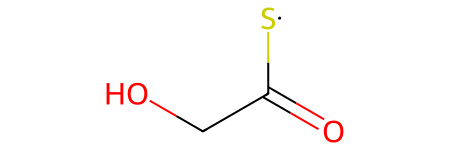

In [50]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

cluster = bcs.Cluster(modules = [loading_module])
mol = cluster.computeProduct(structureDB)

# Convert mol to SMILES
smiles = Chem.MolToSmiles(mol)
print("SMILES:", smiles)
mol

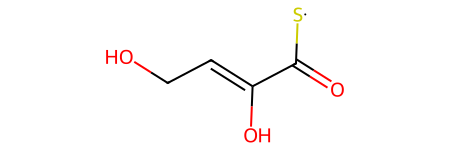

In [51]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

### first extension module with hydroxymalonyl-CoA + DH + KR domain
AT_domain_mod1 = bcs.AT(active = True, substrate = "hmal") 
KR_domain_mod1 = bcs.KR(active = True, type = "B1")
DH_domain_mod1 = bcs.DH(active = True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})

module1 = bcs.Module(domains = mod1_domains_dict, loading = False)

cluster = bcs.Cluster(modules = [loading_module, module1])
mol = cluster.computeProduct(structureDB)
mol

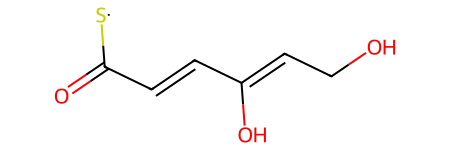

In [52]:
### Create a loading module with hydroxymalonyl-CoA
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active = True, substrate = "Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains = LM_domains_dict, loading = True)

### first extension module with hydroxymalonyl-CoA + DH + KR domain
AT_domain_mod1 = bcs.AT(active = True, substrate = "hmal") 
KR_domain_mod1 = bcs.KR(active = True, type = "B1")
DH_domain_mod1 = bcs.DH(active = True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})

module1 = bcs.Module(domains = mod1_domains_dict, loading = False)

### second extension module with malonyl-CoA+ DH + KR domain
AT_domain_mod2 = bcs.AT(active = True, substrate = "Malonyl-CoA") 
DH_domain_mod2 = bcs.DH(active = True)
KR_domain_mod2 = bcs.KR(active = True, type = "B")
mod2_domains_dict = OrderedDict({bcs.AT: AT_domain_mod2,
                                 bcs.KR: KR_domain_mod2,
                                 bcs.DH: DH_domain_mod2,
                                 })

module2 = bcs.Module(domains = mod2_domains_dict, loading = False)

cluster = bcs.Cluster(modules = [loading_module, 
                                 module1,
                                 module2])

mol_wModule1_wModule2 = cluster.computeProduct(structureDB)
mol_wModule1_wModule2

SMILES: O=C1C=CC(=CCO)O1


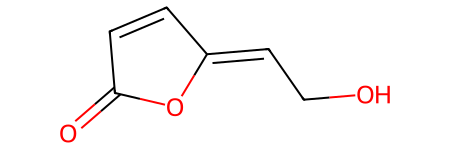

In [53]:
### add PKS release module TE
myTEobject = bcs.TE(active=True, cyclic=True, ring=1)
basidalin_mol_step1 = myTEobject.operation(mol_wModule1_wModule2)
# Convert mol to SMILES
basidalin_mol_step1_smiles = Chem.MolToSmiles(basidalin_mol_step1)
print("SMILES:", basidalin_mol_step1_smiles)
basidalin_mol_step1

### Use DORANET to construct next steps of `Basidalin` synthesis 

### How to diversify `PKS` designs

In [54]:
from retrotide import allModuleTypes, allStarterTypes
print(f"Number of possible starter module: {len(allStarterTypes)}")
print(f"Number of possible starter module: {len(allModuleTypes)}")

Number of possible starter module: 29
Number of possible starter module: 95


In [55]:
allModuleTypes

[["AT{'substrate': 'Methylmalonyl-CoA'}", "KR{'type': 'A2'}", 'loading: False'],
 ["AT{'substrate': 'hmal'}", "KR{'type': 'C1'}", 'loading: False'],
 ["AT{'substrate': 'Malonyl-CoA'}", 'loading: False'],
 ["AT{'substrate': 'emal'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False'],
 ["AT{'substrate': 'isobutmal'}", "KR{'type': 'A1'}", 'loading: False'],
 ["AT{'substrate': 'mxmal'}", "KR{'type': 'A1'}", 'loading: False'],
 ["AT{'substrate': 'allylmal'}", "KR{'type': 'B2'}", 'loading: False'],
 ["AT{'substrate': 'Methylmalonyl-CoA'}", "KR{'type': 'C1'}", 'loading: False'],
 ["AT{'substrate': 'DCP'}", "KR{'type': 'B2'}", 'loading: False'],
 ["AT{'substrate': 'isobutmal'}", "KR{'type': 'B2'}", 'loading: False'],
 ["AT{'substrate': 'D-isobutmal'}", "KR{'type': 'B2'}", 'loading: False'],
 ["AT{'substrate': 'mxmal'}", "KR{'type': 'A2'}", 'loading: False'],
 ["AT{'substrate': 'allylmal'}", "KR{'type': 'A2'}", 'loading: False'],
 ["AT{'substrate': 'DCP'}", "KR{'type': 'A2'}", 'loading: Fal

### Diversify molecules
1. Keep fixed starter, module1, and release module
2. diversify only second extension module

In [56]:
%%time

from rdkit import Chem
from rdkit.Chem import Descriptors
from collections import OrderedDict
import pandas as pd

# Use allModuleTypes list directly - these are already Module objects
allModules = allModuleTypes

print("Number of unique designs in module:", len(allModules))

results = []

print(f"\nCreating diverse molecules with fixed starter, module1, and TE...")
print(f"Varying second extension module from {len(allModules)} possibilities\n")

# Fixed components
AT_domain_with_hydroxymalonyl_coa = bcs.AT(active=True, substrate="Hydroxymalonyl-CoA")
LM_domains_dict = OrderedDict({bcs.AT: AT_domain_with_hydroxymalonyl_coa})
loading_module = bcs.Module(domains=LM_domains_dict, loading=True)

AT_domain_mod1 = bcs.AT(active=True, substrate="hmal") 
KR_domain_mod1 = bcs.KR(active=True, type="B1")
DH_domain_mod1 = bcs.DH(active=True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})
module1 = bcs.Module(domains=mod1_domains_dict, loading=False)

myTEobject = bcs.TE(active=True, cyclic=True, ring=1)

# Create descriptions for fixed modules
starter_description = "AT(Hydroxymalonyl-CoA)"
first_extension_description = "AT(hmal) + KR(B1) + DH"
release_description = "TE(cyclic, ring=1)"

# Iterate through all possible second extension modules
for idx, module2 in enumerate(allModules):
    try:
        # module2 is already a bcs.Module object, use it directly
        cluster = bcs.Cluster(modules=[loading_module, module1, module2])
        mol = cluster.computeProduct(structureDB)  # Added structureDB back
        
        if mol:
            # Apply TE release
            final_mol = myTEobject.operation(mol)
            
            if final_mol:
                smiles = Chem.MolToSmiles(final_mol, canonical=True)
                
                # Calculate molecular weight
                mol_obj = Chem.MolFromSmiles(smiles)
                mol_weight = Descriptors.MolWt(mol_obj) if mol_obj else None
                
                # Create description for module2
                module2_description = str(module2)
                
                results.append({
                    'Canonical_SMILES': smiles,
                    'starter_mod': starter_description,
                    'firstExtension_module': first_extension_description,
                    'secondExtension_mod': module2_description,
                    'release_mod': release_description,
                    'Molecular_Weight': round(mol_weight, 2) if mol_weight else None
                })
                
                if (idx + 1) % 10 == 0:
                    print(f"Processed {idx + 1}/{len(allModules)} modules...")
                    
    except Exception as e:
        # Print full error for debugging
        if idx < 3:
            import traceback
            print(f"\nFull error for module index {idx}:")
            traceback.print_exc()
        continue

# Create DataFrame with columns in specified order
generated_molecules_secondExtensionOnly = pd.DataFrame(results, columns=[
    'Canonical_SMILES',
    'starter_mod',
    'firstExtension_module',
    'secondExtension_mod',
    'release_mod',
    'Molecular_Weight'
])

print(f"\nTotal molecules generated: {len(generated_molecules_secondExtensionOnly)}")
if len(allModules) > 0:
    print(f"Success rate: {len(generated_molecules_secondExtensionOnly)}/{len(allModules)} ({100*len(generated_molecules_secondExtensionOnly)/len(allModules):.1f}%)")

# Drop duplicate SMILES
generated_molecules_secondExtensionOnly = generated_molecules_secondExtensionOnly.drop_duplicates(subset=['Canonical_SMILES'], keep='first')
print(f"\nMolecules left after removing duplicates: {len(generated_molecules_secondExtensionOnly)}")

# Save to CSV
generated_molecules_secondExtensionOnly.to_csv('generated_molecules_secondExtensionOnly.csv', index=False)
print("\nSaved to 'generated_molecules_secondExtensionOnly.csv'")
generated_molecules_secondExtensionOnly

Number of unique designs in module: 95

Creating diverse molecules with fixed starter, module1, and TE...
Varying second extension module from 95 possibilities

Processed 10/95 modules...
Processed 20/95 modules...
Processed 30/95 modules...
Processed 40/95 modules...
Processed 50/95 modules...
Processed 60/95 modules...
Processed 70/95 modules...
Processed 80/95 modules...
Processed 90/95 modules...

Total molecules generated: 95
Success rate: 95/95 (100.0%)

Molecules left after removing duplicates: 79

Saved to 'generated_molecules_secondExtensionOnly.csv'
CPU times: user 56.7 ms, sys: 978 μs, total: 57.7 ms
Wall time: 57.8 ms


,Canonical_SMILES,starter_mod,firstExtension_module,secondExtension_mod,release_mod,Molecular_Weight
0,C[C@@H]1C(=O)O[C@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...","TE(cyclic, ring=1)",158.15
1,O=C1OCC=C(O)C(=O)[C@H]1O,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hmal'}"", ""KR{'type': 'C1'}""...","TE(cyclic, ring=1)",158.11
2,O=C1CC(=O)C(=CCO)O1,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Malonyl-CoA'}"", 'loading: F...","TE(cyclic, ring=1)",142.11
3,CC[C@H]1CC(=CCO)OC1=O,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'B1'}""...","TE(cyclic, ring=1)",156.18
4,CC(C)[C@H]1C(=O)O[C@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'isobutmal'}"", ""KR{'type': '...","TE(cyclic, ring=1)",186.21
...,...,...,...,...,...,...
87,C[C@@H]1C(=O)O[C@@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...","TE(cyclic, ring=1)",158.15
88,CCCCCC[C@H]1C(=O)O[C@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'A1'...","TE(cyclic, ring=1)",228.29
90,CCCC[C@H]1CC(=CCO)OC1=O,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'butmal'}"", ""KR{'type': 'B1'...","TE(cyclic, ring=1)",184.23
92,CC[C@H]1C(=O)O[C@H]1C(O)=CCO,AT(Hydroxymalonyl-CoA),AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'A1'}""...","TE(cyclic, ring=1)",172.18


### Display molecules

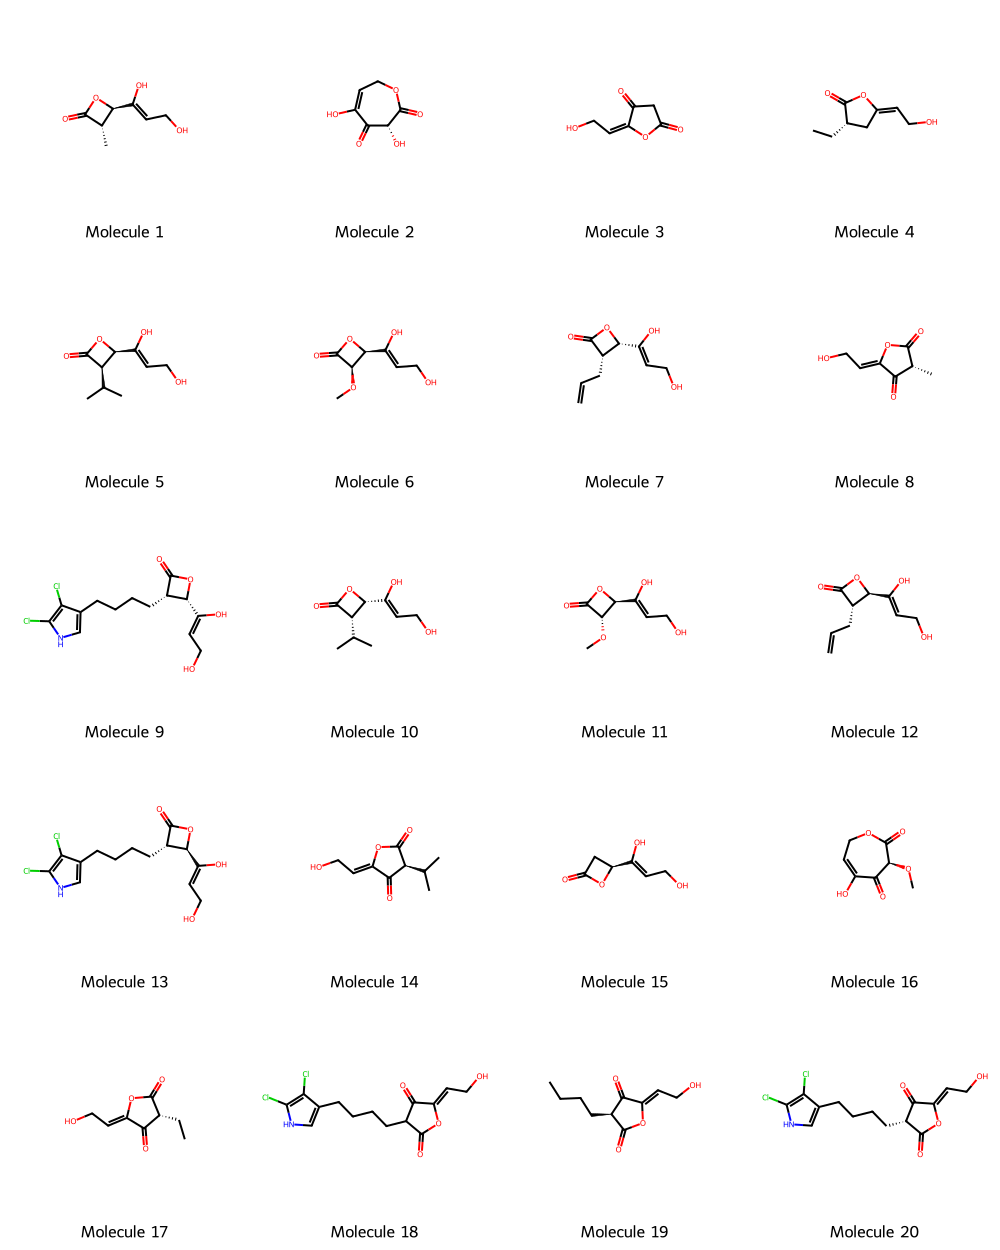

In [57]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES back to molecules for visualization
mols = [Chem.MolFromSmiles(smiles) for smiles in generated_molecules_secondExtensionOnly['Canonical_SMILES'].head(20)]

# Create a grid of molecules
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 250),
                           legends=[f"Molecule {i+1}" for i in range(len(mols))])
display(img)

### Diversify molecules
1. Keep fixed module1 and release module
2. diversify only starter and second extension module

In [58]:
from retrotide import allModuleTypes, allStarterTypes
len(allModuleTypes)

95

In [59]:
len(allStarterTypes)

29

In [60]:
%%time

from rdkit import Chem
from rdkit.Chem import Descriptors
from collections import OrderedDict
from collections import defaultdict
import pandas as pd

# Use separate lists for starters and second extensions
allStarters = allStarterTypes
allSecondExtensions = allModuleTypes

print("Number of unique starter modules:", len(allStarters))
print("Number of unique second extension modules:", len(allSecondExtensions))
print(f"Maximum possible combinations: {len(allStarters)} starters × {len(allSecondExtensions)} second extensions = {len(allStarters) * len(allSecondExtensions)}")

results = []

# Track failures
failure_reasons = {
    'no_product_from_computeProduct': 0,
    'no_final_mol_from_TE': 0,
    'exception_errors': 0
}

# Track release types dynamically
release_counts = defaultdict(int)

print(f"\nCreating diverse molecules with variable starter and module2...")
print(f"Keeping module1 and TE fixed\n")

# Fixed components (module1 and TE only)
AT_domain_mod1 = bcs.AT(active=True, substrate="hmal") 
KR_domain_mod1 = bcs.KR(active=True, type="B1")
DH_domain_mod1 = bcs.DH(active=True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})
module1 = bcs.Module(domains=mod1_domains_dict, loading=False)

# Fixed descriptions
first_extension_description = "AT(hmal) + KR(B1) + DH"

# Maximum ring positions to try before falling back to linear
max_ring_to_try = 10  # Set high enough to cover all possible cases

# Nested loop: iterate through all starter and second extension combinations
total_combinations = len(allStarters) * len(allSecondExtensions)
processed = 0

### Module sequence: Starter | first extension | second extension | release

for starter_idx, starter_module in enumerate(allStarters):   #### <<<<<<<<<<<<<<< starter outer loop >>>>>>>>>>>>>>
    # Create loading module from starter_module domains
    # Force loading=True for the starter
    loading_module = bcs.Module(domains=starter_module.domains, loading=True)
    starter_description = str(starter_module)
    
    for mod2_idx, module2 in enumerate(allSecondExtensions):     ### <<<<<<<<<<<<<<< extension inner loop >>>>>>>>>>>>>>
        processed += 1
        
        try:
            # Create cluster with variable starter, fixed module1, and variable module2
            cluster = bcs.Cluster(modules=[loading_module, module1, module2])
            mol = cluster.computeProduct(structureDB)
            
            if mol:
                # Try different ring positions for cyclic release
                final_mol = None
                release_description = None
                
                # Try cyclic release with different ring positions   ### <<<<<<<<<<<<<<< release inner loop >>>>>>>>>>>>>>
                ### keep only right size of the rings
                for ring_num in range(0, max_ring_to_try + 1):
                    try:
                        te_cyclic = bcs.TE(active=True, cyclic=True, ring=ring_num)
                        final_mol = te_cyclic.operation(mol)
                        if final_mol:
                            release_description = f"TE(cyclic, ring={ring_num})"
                            release_counts[f'cyclic_ring_{ring_num}'] += 1
                            break
                    except (IndexError, Exception):
                        continue
                
                # If all cyclic attempts failed, try linear
                if not final_mol:
                    try:
                        te_linear = bcs.TE(active=True, cyclic=False, ring=0)
                        final_mol = te_linear.operation(mol)
                        if final_mol:
                            release_description = "TE(linear)"
                            release_counts['linear'] += 1
                    except (IndexError, Exception):
                        pass
                
                if final_mol:
                    smiles = Chem.MolToSmiles(final_mol, canonical=True)
                    
                    # Calculate molecular weight
                    mol_obj = Chem.MolFromSmiles(smiles)
                    mol_weight = Descriptors.MolWt(mol_obj) if mol_obj else None
                    
                    # Create description for module2
                    module2_description = str(module2)
                    
                    results.append({
                        'Canonical_SMILES': smiles,
                        'starter_mod': starter_description,
                        'firstExtension_module': first_extension_description,
                        'secondExtension_mod': module2_description,
                        'release_mod': release_description,
                        'Molecular_Weight': round(mol_weight, 2) if mol_weight else None
                    })
                else:
                    # All TE options failed
                    failure_reasons['no_final_mol_from_TE'] += 1
                    if failure_reasons['no_final_mol_from_TE'] <= 3:
                        print(f"All TE options failed for starter={starter_idx}, mod2={mod2_idx}")
            else:
                # computeProduct returned None
                failure_reasons['no_product_from_computeProduct'] += 1
                if failure_reasons['no_product_from_computeProduct'] <= 3:
                    print(f"computeProduct failed for starter={starter_idx}, mod2={mod2_idx}")
                    
            if processed % 1000 == 0:
                print(f"Processed {processed}/{total_combinations} combinations ({100*processed/total_combinations:.1f}%)...")
                        
        except Exception as e:
            failure_reasons['exception_errors'] += 1
            if failure_reasons['exception_errors'] <= 3:
                import traceback
                print(f"\nException for combination (starter={starter_idx}, mod2={mod2_idx}):")
                traceback.print_exc()
            continue

# Create DataFrame
generated_molecules_diverseStarterSecondExtension = pd.DataFrame(results, columns=[
    'Canonical_SMILES',
    'starter_mod',
    'firstExtension_module',
    'secondExtension_mod',
    'release_mod',
    'Molecular_Weight'
])



print("\nSummary:")
print(f"Starter modules used: {len(allStarters)}")
print(f"Second extension modules used: {len(allSecondExtensions)}")
print(f"Total molecules generated: {len(generated_molecules_diverseStarterSecondExtension)}")
print(f"Success rate: {len(generated_molecules_diverseStarterSecondExtension)}/{total_combinations} ({100*len(generated_molecules_diverseStarterSecondExtension)/total_combinations:.1f}%)")

# Print release type breakdown
print("\nRelease type breakdown:")
total_generated = sum(release_counts.values())
cyclic_counts = {k: v for k, v in release_counts.items() if 'cyclic' in k and v > 0}
total_cyclic = sum(cyclic_counts.values())
total_linear = release_counts.get('linear', 0)

if total_generated > 0:
    print(f"  Total cyclic releases: {total_cyclic} ({100*total_cyclic/total_generated:.1f}%)")
    # Sort by ring number and display
    sorted_cyclic = sorted(cyclic_counts.items(), key=lambda x: int(x[0].split('_')[-1]))
    for key, count in sorted_cyclic:
        ring_num = key.split('_')[-1]
        print(f"    - Ring position {ring_num}: {count} ({100*count/total_generated:.1f}%)")
    print(f"  Linear fallback release: {total_linear} ({100*total_linear/total_generated:.1f}%)")
else:
    print(f"  Total cyclic releases: {total_cyclic}")
    print(f"  Linear fallback release: {total_linear}")

print("\nFailed combinations:")
successful = len(generated_molecules_diverseStarterSecondExtension)
total_failed = total_combinations - successful

for reason, count in failure_reasons.items():
    percentage = (count/total_combinations)*100 if total_combinations > 0 else 0
    print(f"  {reason}: {count} ({percentage:.1f}%)")

print(f"\nTotal successful: {successful} ({100*successful/total_combinations:.1f}%)")
print(f"Total failed: {total_failed} ({100*total_failed/total_combinations:.1f}%)")

# Drop duplicate SMILES
original_count = len(generated_molecules_diverseStarterSecondExtension)
generated_molecules_diverseStarterSecondExtension = generated_molecules_diverseStarterSecondExtension.drop_duplicates(subset=['Canonical_SMILES'], keep='first')
print(f"\nMolecules before deduplication: {original_count}")
print(f"Unique molecules after removing duplicates: {len(generated_molecules_diverseStarterSecondExtension)}")
if original_count > 0:
    print(f"Duplicates removed: {original_count - len(generated_molecules_diverseStarterSecondExtension)} ({100*(original_count - len(generated_molecules_diverseStarterSecondExtension))/original_count:.1f}% of generated)")

# Print release type breakdown after deduplication
print("\nRelease type after deduplication:")
cyclic_after_dedup = len(generated_molecules_diverseStarterSecondExtension[generated_molecules_diverseStarterSecondExtension['release_mod'].str.contains('cyclic', na=False)])
linear_after_dedup = len(generated_molecules_diverseStarterSecondExtension[generated_molecules_diverseStarterSecondExtension['release_mod'].str.contains('linear', na=False)])
total_after_dedup = cyclic_after_dedup + linear_after_dedup

if total_after_dedup > 0:
    print(f"  Total cyclic release: {cyclic_after_dedup} ({100*cyclic_after_dedup/total_after_dedup:.1f}%)")
    # Breakdown by ring position after dedup
    for ring_num in range(1, max_ring_to_try + 1):
        ring_count = len(generated_molecules_diverseStarterSecondExtension[generated_molecules_diverseStarterSecondExtension['release_mod'] == f'TE(cyclic, ring={ring_num})'])
        if ring_count > 0:
            print(f"    - Ring position {ring_num}: {ring_count} ({100*ring_count/total_after_dedup:.1f}%)")
    print(f"  Linear fallback release: {linear_after_dedup} ({100*linear_after_dedup/total_after_dedup:.1f}%)")
else:
    print(f"  Cyclic release: {cyclic_after_dedup}")
    print(f"  Linear fallback release: {linear_after_dedup}")

# Save to CSV
generated_molecules_diverseStarterSecondExtension.to_csv('generated_molecules_diverseStarterSecondExtension.csv', index=False)
print("\nSaved to 'generated_molecules_diverseStarterSecondExtension.csv'")
generated_molecules_diverseStarterSecondExtension.shape

Number of unique starter modules: 29
Number of unique second extension modules: 95
Maximum possible combinations: 29 starters × 95 second extensions = 2755

Creating diverse molecules with variable starter and module2...
Keeping module1 and TE fixed

Processed 1000/2755 combinations (36.3%)...
Processed 2000/2755 combinations (72.6%)...

Summary:
Starter modules used: 29
Second extension modules used: 95
Total molecules generated: 2755
Success rate: 2755/2755 (100.0%)

Release type breakdown:
  Total cyclic releases: 2755 (100.0%)
    - Ring position 0: 2478 (89.9%)
    - Ring position 1: 273 (9.9%)
    - Ring position 2: 4 (0.1%)
  Linear fallback release: 0 (0.0%)

Failed combinations:
  no_product_from_computeProduct: 0 (0.0%)
  no_final_mol_from_TE: 0 (0.0%)
  exception_errors: 0 (0.0%)

Total successful: 2755 (100.0%)
Total failed: 0 (0.0%)

Molecules before deduplication: 2755
Unique molecules after removing duplicates: 2054
Duplicates removed: 701 (25.4% of generated)

Release t

(2054, 6)

### Display molecules

,Canonical_SMILES,Structure,starter_mod,secondExtension_mod,release_mod,Molecular_Weight
0,CCC=C(O)[C@@H]1OC(=O)[C@H]1C,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'type': 'A2'}"", 'loading: False']","TE(cyclic, ring=0)",156.18
1,CCC=C(O)C(=O)[C@H]1OC1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'hmal'}"", ""KR{'type': 'C1'}"", 'loading: False']","TE(cyclic, ring=0)",156.14
2,CCC=C1OC(=O)CC1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'Malonyl-CoA'}"", 'loading: False']","TE(cyclic, ring=0)",140.14
3,CCC=C1C[C@H](CC)C(=O)O1,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'emal'}"", ""KR{'type': 'B1'}"", 'DH{}', 'ER{}', 'loading: False']","TE(cyclic, ring=0)",154.21
4,CCC=C(O)[C@@H]1OC(=O)[C@@H]1C(C)C,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'isobutmal'}"", ""KR{'type': 'A1'}"", 'loading: False']","TE(cyclic, ring=0)",184.23
5,CCC=C(O)[C@@H]1OC(=O)[C@@H]1OC,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'mxmal'}"", ""KR{'type': 'A1'}"", 'loading: False']","TE(cyclic, ring=1)",172.18
6,C=CC[C@@H]1C(=O)O[C@@H]1C(O)=CCC,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'allylmal'}"", ""KR{'type': 'B2'}"", 'loading: False']","TE(cyclic, ring=0)",182.22
7,CCC=C1OC(=O)[C@H](C)C1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'type': 'C1'}"", 'loading: False']","TE(cyclic, ring=0)",154.16
8,CCC=C(O)[C@H]1OC(=O)[C@H]1CCCCc1c[nH]c(Cl)c1Cl,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'DCP'}"", ""KR{'type': 'B2'}"", 'loading: False']","TE(cyclic, ring=0)",332.23
9,CCC=C(O)[C@H]1OC(=O)[C@H]1C(C)C,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'isobutmal'}"", ""KR{'type': 'B2'}"", 'loading: False']","TE(cyclic, ring=0)",184.23

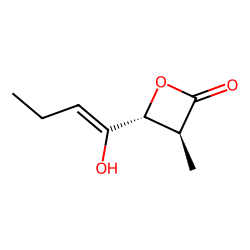
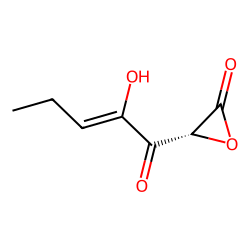
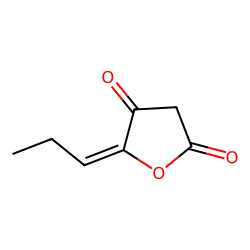
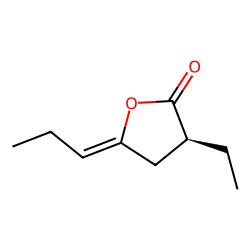
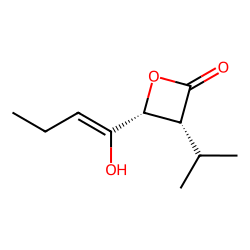
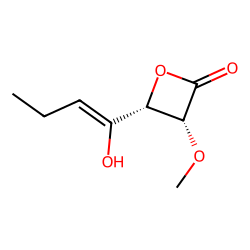
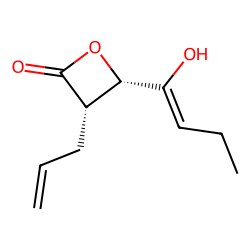
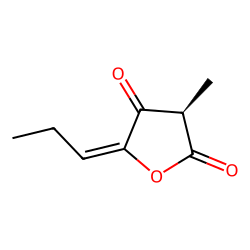
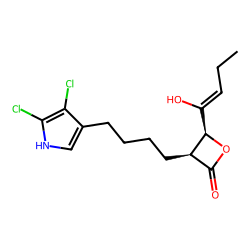
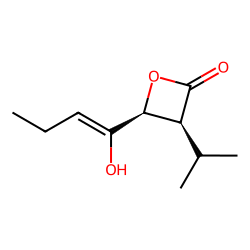
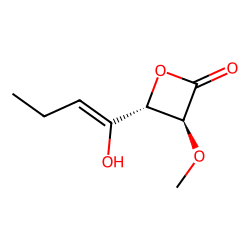
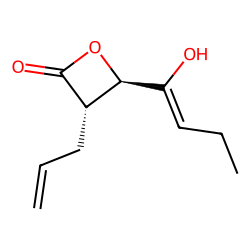
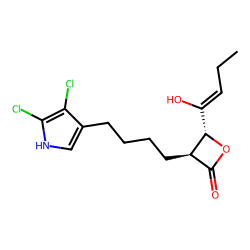
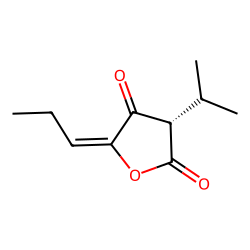
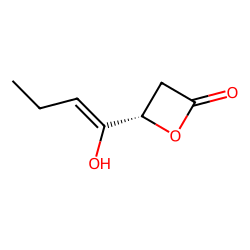
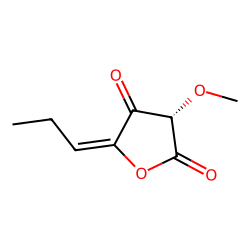
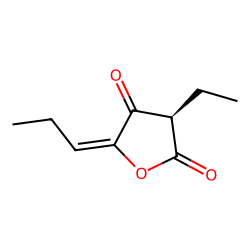
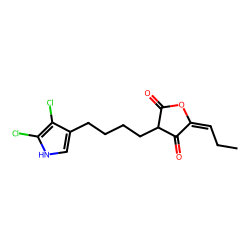
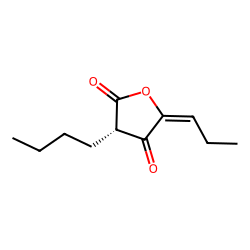
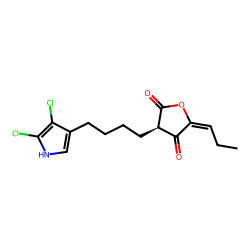
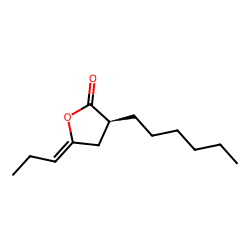
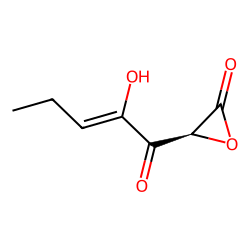
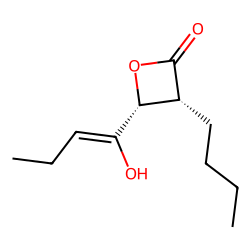
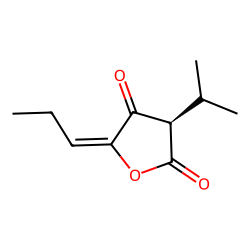
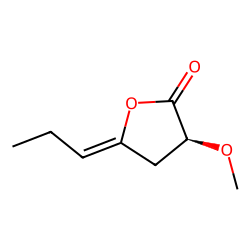
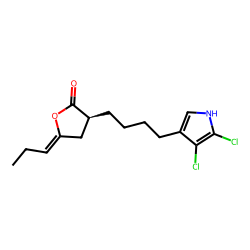
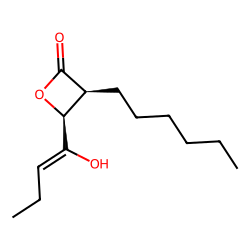
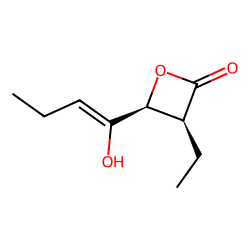
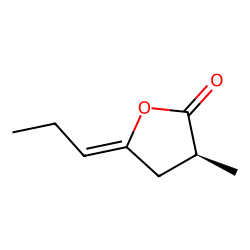
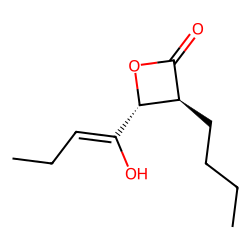
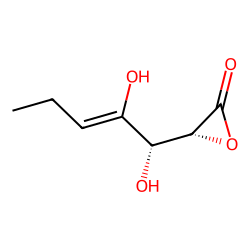
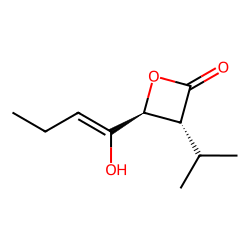
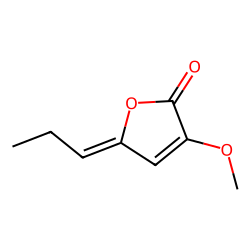
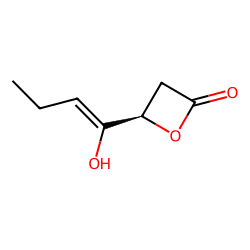
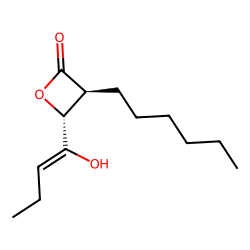
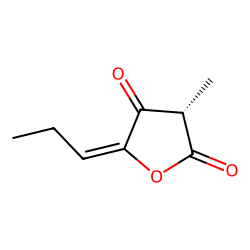
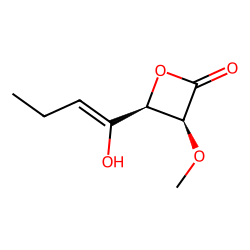
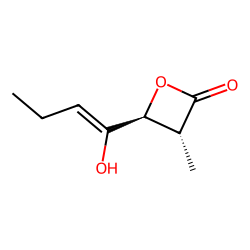
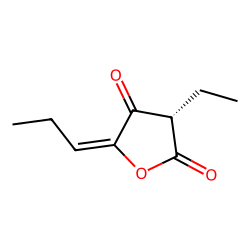
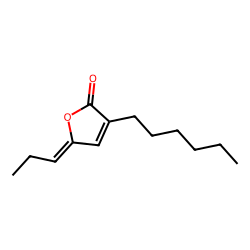
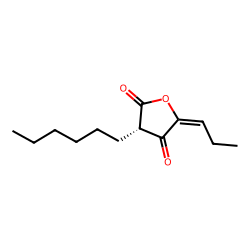
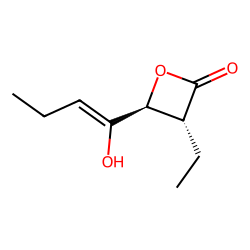
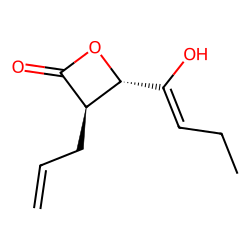
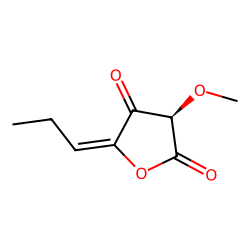
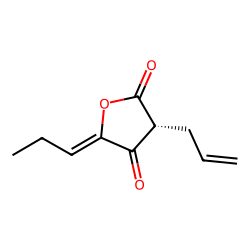
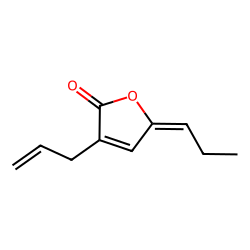
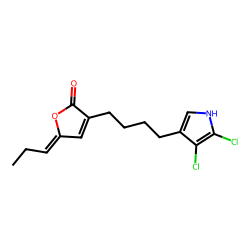
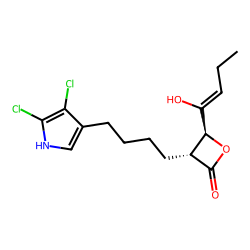
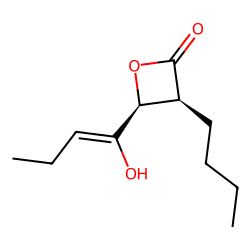
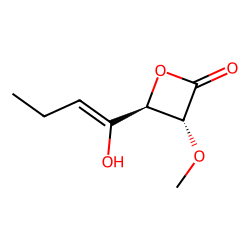
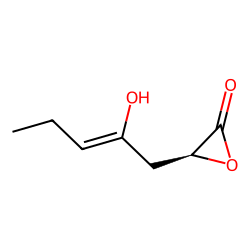
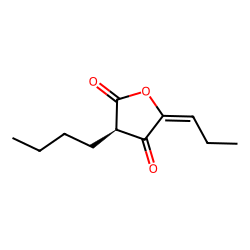
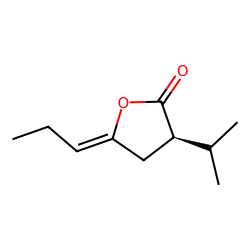
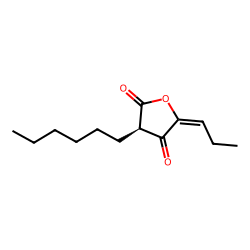
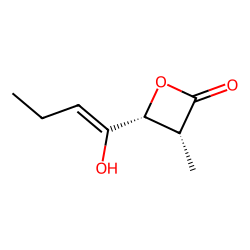
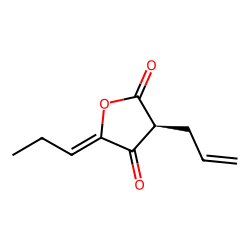
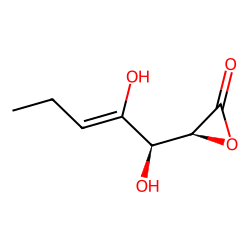
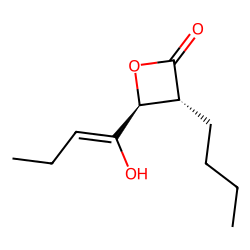
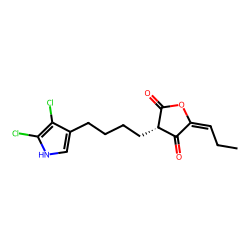
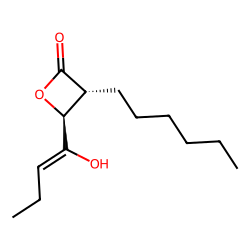
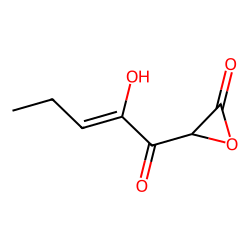
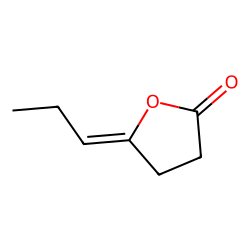
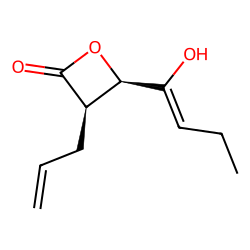
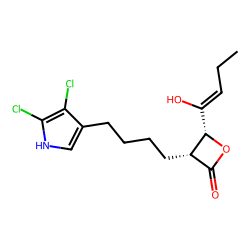
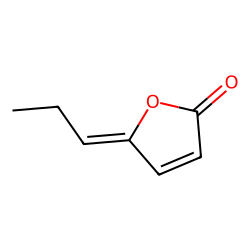
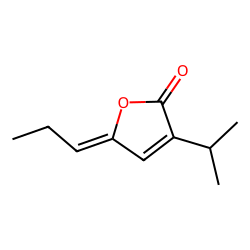
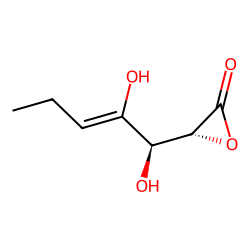
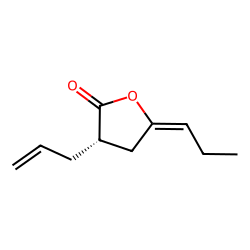
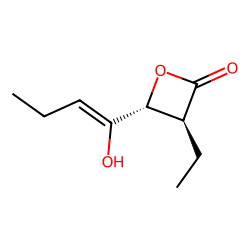
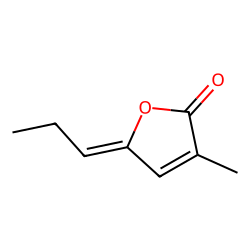
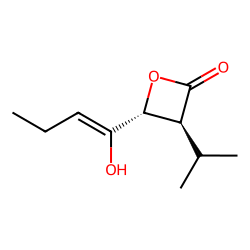
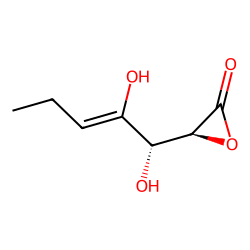
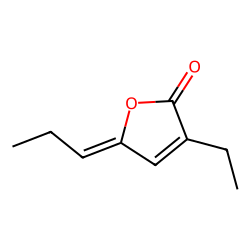
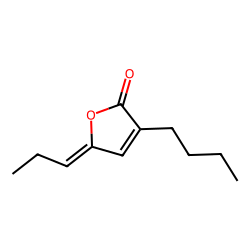
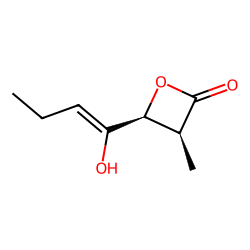
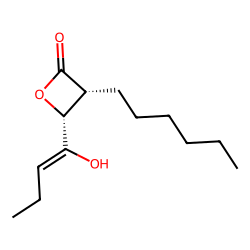
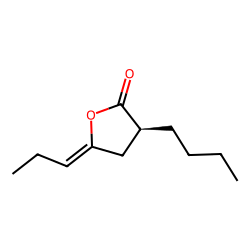
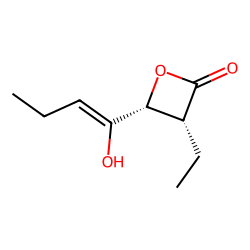
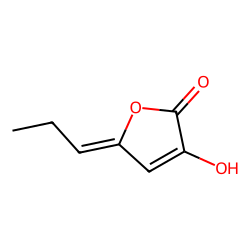
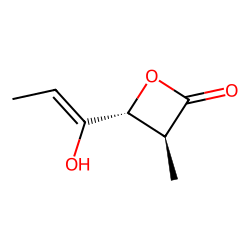
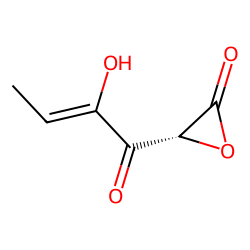
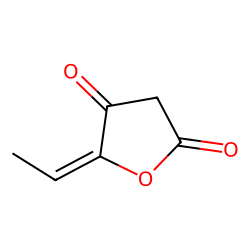
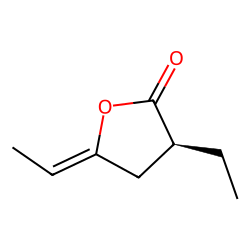
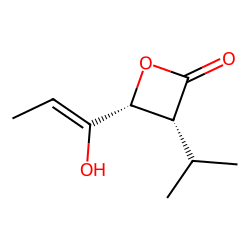
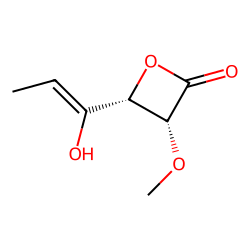
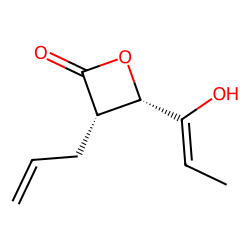
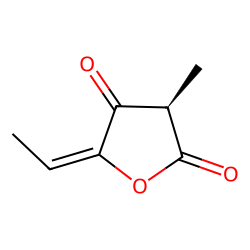
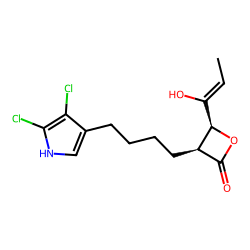
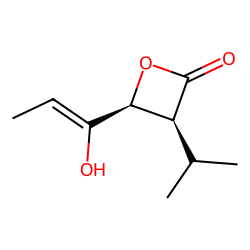
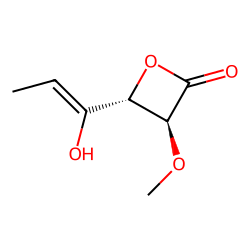
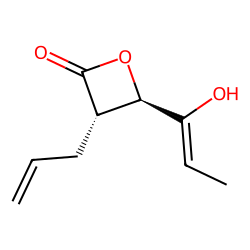
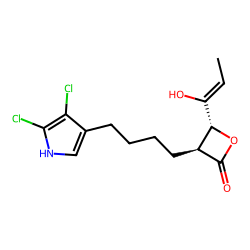
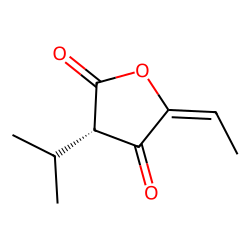
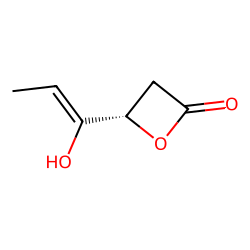
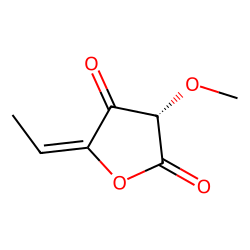
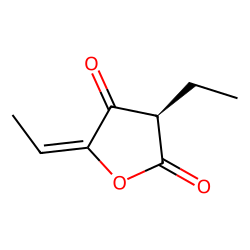
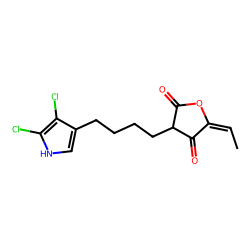
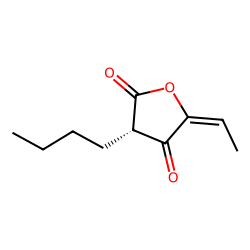
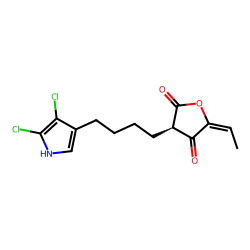
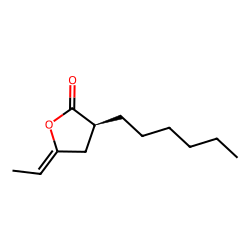

In [62]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, HTML
import pandas as pd
from io import BytesIO
import base64

def mol_to_img_html(smiles, size=(250, 250)):
    """
    Convert SMILES to an HTML img tag with embedded base64 image.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "Invalid SMILES"
    
    img = Draw.MolToImage(mol, size=size)
    
    # Convert image to base64
    buffered = BytesIO()
    img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    
    return f'<img src="data:image/png;base64,{img_str}" width="{size[0]}" height="{size[1]}">'


# Create a subset DataFrame for visualization
moleculesDF_display = generated_molecules_diverseStarterSecondExtension.head(100).copy()

# Add structure images as HTML
moleculesDF_display['Structure'] = moleculesDF_display['Canonical_SMILES'].apply(mol_to_img_html)

# Select columns to display
columns_to_show = ['Canonical_SMILES', 'Structure', 'starter_mod', 'secondExtension_mod', 'release_mod', 'Molecular_Weight']
moleculesDF_display = moleculesDF_display[columns_to_show]

# Display as HTML table with images
display(HTML(moleculesDF_display.to_html(escape=False)))

### Diversify molecules
1. Keep fixed module1 and release module
2. diversify only starter and second extension module
3. Define the target substructures to preserve

### USE ONLY EXACT `SMILES patterns`

In [64]:
%%time

from rdkit import Chem
from rdkit.Chem import Descriptors
from collections import OrderedDict
from collections import defaultdict
import pandas as pd

# Define the target substructures to preserve (your exact SMILES)
TARGET_SUBSTRUCTURES = [
    'CCC=C1C[C@H](OC)C(=O)O1',  # First pattern 
    'CCC=C1C=CC(=O)O1',         # Second pattern
    'CCC=C1OC(=O)[C@@H](C(C)C)C1=O',
    'CCC=C1OC(=O)CC1=O',    
    'CCC=C1OC(=O)[C@H](C)C1=O',       
]

# Convert to RDKit mol objects for substructure matching
target_mols = []
for smiles in TARGET_SUBSTRUCTURES:
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        target_mols.append(mol)
        print(f"Loaded target substructure: {smiles}")

print(f"\nTotal target substructures loaded: {len(target_mols)}")


def has_target_substructure(mol):
    """
    Check if molecule contains any of the target substructures.
    Returns True if any target substructure is found.
    """
    if mol is None:
        return False
    
    for target in target_mols:
        if mol.HasSubstructMatch(target):
            return True
    
    return False


def get_matching_pattern(mol):
    """
    Return which target substructure(s) the molecule matches.
    """
    if mol is None:
        return None
    
    matches = []
    for i, target in enumerate(target_mols):
        if mol.HasSubstructMatch(target):
            matches.append(f"pattern_{i+1}: {TARGET_SUBSTRUCTURES[i]}")
    
    return matches if matches else None


# Use separate lists for starters and second extensions
allStarters = allStarterTypes
allSecondExtensions = allModuleTypes

print("\nNumber of unique starter modules:", len(allStarters))
print("Number of unique second extension modules:", len(allSecondExtensions))
print(f"Maximum possible combinations: {len(allStarters)} starters × {len(allSecondExtensions)} second extensions = {len(allStarters) * len(allSecondExtensions)}")

results = []

# Track failures
failure_reasons = {
    'no_product_from_computeProduct': 0,
    'no_final_mol_from_TE': 0,
    'no_matching_substructure': 0,
    'exception_errors': 0
}

# Track release types dynamically
release_counts = defaultdict(int)

# Track which target pattern matched
pattern_match_counts = defaultdict(int)

print(f"\nCreating diverse molecules with variable starter and module2...")
print(f"Keeping module1 and TE fixed")
print(f"Filtering for target substructures\n")

# Fixed components (module1 and TE only)
AT_domain_mod1 = bcs.AT(active=True, substrate="hmal") 
KR_domain_mod1 = bcs.KR(active=True, type="B1")
DH_domain_mod1 = bcs.DH(active=True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})
module1 = bcs.Module(domains=mod1_domains_dict, loading=False)

# Fixed descriptions
first_extension_description = "AT(hmal) + KR(B1) + DH"

# Maximum ring positions to try before falling back to linear
max_ring_to_try = 20

# Nested loop: iterate through all starter and second extension combinations
total_combinations = len(allStarters) * len(allSecondExtensions)
processed = 0

for starter_idx, starter_module in enumerate(allStarters):
    loading_module = bcs.Module(domains=starter_module.domains, loading=True)
    starter_description = str(starter_module)
    
    for mod2_idx, module2 in enumerate(allSecondExtensions):
        processed += 1
        
        try:
            cluster = bcs.Cluster(modules=[loading_module, module1, module2])
            mol = cluster.computeProduct(structureDB)
            
            if mol:
                final_mol = None
                release_description = None
                
                # Try cyclic release - only keep if has target substructure
                for ring_num in range(0, max_ring_to_try + 1):
                    try:
                        te_cyclic = bcs.TE(active=True, cyclic=True, ring=ring_num)
                        candidate_mol = te_cyclic.operation(mol)
                        
                        if candidate_mol:
                            # Only accept if molecule has target substructure
                            if has_target_substructure(candidate_mol):
                                final_mol = candidate_mol
                                release_description = f"TE(cyclic, ring={ring_num})"
                                release_counts[f'cyclic_ring_{ring_num}'] += 1
                                
                                # Track which pattern matched
                                matching = get_matching_pattern(candidate_mol)
                                if matching:
                                    for pattern in matching:
                                        pattern_match_counts[pattern] += 1
                                break
                                
                    except (IndexError, Exception):
                        continue
                
                # If no cyclic with target substructure found, try linear
                if not final_mol:
                    try:
                        te_linear = bcs.TE(active=True, cyclic=False, ring=0)
                        candidate_mol = te_linear.operation(mol)
                        
                        if candidate_mol:
                            final_mol = candidate_mol
                            release_description = "TE(linear)"
                            release_counts['linear'] += 1
                            
                    except (IndexError, Exception):
                        pass
                
                if final_mol:
                    smiles = Chem.MolToSmiles(final_mol, canonical=True)
                    mol_obj = Chem.MolFromSmiles(smiles)
                    mol_weight = Descriptors.MolWt(mol_obj) if mol_obj else None
                    module2_description = str(module2)
                    
                    has_target = has_target_substructure(mol_obj)
                    matching = get_matching_pattern(mol_obj)
                    
                    results.append({
                        'Canonical_SMILES': smiles,
                        'starter_mod': starter_description,
                        'firstExtension_module': first_extension_description,
                        'secondExtension_mod': module2_description,
                        'release_mod': release_description,
                        'Molecular_Weight': round(mol_weight, 2) if mol_weight else None,
                        'has_target_substructure': has_target,
                        'matching_patterns': str(matching) if matching else None
                    })
                else:
                    failure_reasons['no_final_mol_from_TE'] += 1
            else:
                failure_reasons['no_product_from_computeProduct'] += 1
                    
            if processed % 1000 == 0:
                print(f"Processed {processed}/{total_combinations} combinations ({100*processed/total_combinations:.1f}%)...")
                        
        except Exception as e:
            failure_reasons['exception_errors'] += 1
            if failure_reasons['exception_errors'] <= 3:
                import traceback
                print(f"\nException for combination (starter={starter_idx}, mod2={mod2_idx}):")
                traceback.print_exc()
            continue

# Create DataFrame
generated_molecules_diverseStarterSecondExtensionSMILES = pd.DataFrame(results, columns=[
    'Canonical_SMILES',
    'starter_mod',
    'firstExtension_module',
    'secondExtension_mod',
    'release_mod',
    'Molecular_Weight',
    'has_target_substructure',
    'matching_patterns'
])


print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Starter modules used: {len(allStarters)}")
print(f"Second extension modules used: {len(allSecondExtensions)}")
print(f"Total molecules generated: {len(generated_molecules_diverseStarterSecondExtensionSMILES)}")

# Release type breakdown
print("\nRelease type breakdown:")
total_generated = sum(release_counts.values())
cyclic_counts = {k: v for k, v in release_counts.items() if 'cyclic' in k and v > 0}
total_cyclic = sum(cyclic_counts.values())
total_linear = release_counts.get('linear', 0)

if total_generated > 0:
    print(f"  Total cyclic releases: {total_cyclic} ({100*total_cyclic/total_generated:.1f}%)")
    sorted_cyclic = sorted(cyclic_counts.items(), key=lambda x: int(x[0].split('_')[-1]))
    for key, count in sorted_cyclic:
        ring_num = key.split('_')[-1]
        print(f"    - Ring position {ring_num}: {count} ({100*count/total_generated:.1f}%)")
    print(f"  Linear fallback release: {total_linear} ({100*total_linear/total_generated:.1f}%)")

# Pattern match breakdown
print("\nTarget substructure match breakdown:")
if pattern_match_counts:
    for pattern, count in sorted(pattern_match_counts.items()):
        print(f"  {pattern}: {count}")
else:
    print("  No matches found")

# Target substructure statistics
total_mols = len(generated_molecules_diverseStarterSecondExtensionSMILES)
mols_with_target = generated_molecules_diverseStarterSecondExtensionSMILES['has_target_substructure'].sum()
print(f"\nMolecules with target substructure: {mols_with_target} ({100*mols_with_target/total_mols:.1f}%)")

print("\nFailed combinations:")
for reason, count in failure_reasons.items():
    percentage = (count/total_combinations)*100 if total_combinations > 0 else 0
    print(f"  {reason}: {count} ({percentage:.1f}%)")

# Deduplication
original_count = len(generated_molecules_diverseStarterSecondExtensionSMILES)
generated_molecules_diverseStarterSecondExtensionSMILES = generated_molecules_diverseStarterSecondExtensionSMILES.drop_duplicates(subset=['Canonical_SMILES'], keep='first')
print(f"\nMolecules before deduplication: {original_count}")
print(f"Unique molecules after removing duplicates: {len(generated_molecules_diverseStarterSecondExtensionSMILES)}")

# Save
generated_molecules_diverseStarterSecondExtensionSMILES.to_csv('generated_molecules_diverseStarterSecondExtensionSMILES.csv', index=False)
print("\nSaved to 'generated_molecules_diverseStarterSecondExtensionSMILES.csv'")

generated_molecules_diverseStarterSecondExtensionSMILES

Loaded target substructure: CCC=C1C[C@H](OC)C(=O)O1
Loaded target substructure: CCC=C1C=CC(=O)O1
Loaded target substructure: CCC=C1OC(=O)[C@@H](C(C)C)C1=O
Loaded target substructure: CCC=C1OC(=O)CC1=O
Loaded target substructure: CCC=C1OC(=O)[C@H](C)C1=O

Total target substructures loaded: 5

Number of unique starter modules: 29
Number of unique second extension modules: 95
Maximum possible combinations: 29 starters × 95 second extensions = 2755

Creating diverse molecules with variable starter and module2...
Keeping module1 and TE fixed
Filtering for target substructures

Processed 1000/2755 combinations (36.3%)...
Processed 2000/2755 combinations (72.6%)...

SUMMARY
Starter modules used: 29
Second extension modules used: 95
Total molecules generated: 2755

Release type breakdown:
  Total cyclic releases: 705 (25.6%)
    - Ring position 0: 360 (13.1%)
    - Ring position 1: 142 (5.2%)
    - Ring position 2: 14 (0.5%)
    - Ring position 3: 40 (1.5%)
    - Ring position 4: 116 (4.2%)
  

,Canonical_SMILES,starter_mod,firstExtension_module,secondExtension_mod,release_mod,Molecular_Weight,has_target_substructure,matching_patterns
0,CCC=C(O)[C@H](O)[C@H](C)C(=O)O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",TE(linear),174.20,False,None
1,CCC=C1OC(=O)[C@H](O)C1=O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hmal'}"", ""KR{'type': 'C1'}""...","TE(cyclic, ring=1)",156.14,True,['pattern_4: CCC=C1OC(=O)CC1=O']
2,CCC=C1OC(=O)CC1=O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Malonyl-CoA'}"", 'loading: F...","TE(cyclic, ring=0)",140.14,True,['pattern_4: CCC=C1OC(=O)CC1=O']
3,CCC=C(O)C[C@H](CC)C(=O)O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'B1'}""...",TE(linear),172.22,False,None
4,CCC=C(O)[C@H](O)[C@H](C(=O)O)C(C)C,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'isobutmal'}"", ""KR{'type': '...",TE(linear),202.25,False,None
...,...,...,...,...,...,...,...,...
2747,C[C@H](C=C(O)[C@@H](O)[C@H](C)C(=O)O)CNC(=O)[C...,"[""AT{'substrate': '3measp'}"", 'loading: True']",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...",TE(linear),274.32,False,None
2748,CCCCCC[C@@H](C(=O)O)[C@@H](O)C(O)=C[C@@H](C)CN...,"[""AT{'substrate': '3measp'}"", 'loading: True']",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'A1'...",TE(linear),344.45,False,None
2750,CCCC[C@@H](CC(O)=C[C@@H](C)CNC(=O)[C@H](C)N)C(...,"[""AT{'substrate': '3measp'}"", 'loading: True']",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'butmal'}"", ""KR{'type': 'B1'...",TE(linear),300.40,False,None
2752,CC[C@@H](C(=O)O)[C@@H](O)C(O)=C[C@@H](C)CNC(=O...,"[""AT{'substrate': '3measp'}"", 'loading: True']",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'A1'}""...",TE(linear),288.34,False,None


,Canonical_SMILES,Structure,starter_mod,secondExtension_mod,release_mod,Molecular_Weight
1,CCC=C1OC(=O)[C@H](O)C1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'hmal'}"", ""KR{'type': 'C1'}"", 'loading: False']","TE(cyclic, ring=1)",156.14
2,CCC=C1OC(=O)CC1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'Malonyl-CoA'}"", 'loading: False']","TE(cyclic, ring=0)",140.14
5,CCC=C1OC(=O)[C@H](OC)[C@H]1O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'mxmal'}"", ""KR{'type': 'A1'}"", 'loading: False']","TE(cyclic, ring=3)",172.18
7,CCC=C1OC(=O)[C@H](C)C1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'type': 'C1'}"", 'loading: False']","TE(cyclic, ring=0)",154.16
11,CCC=C1OC(=O)[C@@H](OC)[C@H]1O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'mxmal'}"", ""KR{'type': 'A2'}"", 'loading: False']","TE(cyclic, ring=3)",172.18
14,CCC=C1OC(=O)[C@@H](C(C)C)C1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'D-isobutmal'}"", ""KR{'type': 'C2'}"", 'loading: False']","TE(cyclic, ring=0)",182.22
16,CCC=C1OC(=O)[C@@H](OC)C1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'mxmal'}"", ""KR{'type': 'C2'}"", 'loading: False']","TE(cyclic, ring=1)",170.16
17,CCC=C1OC(=O)[C@H](CC)C1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'emal'}"", ""KR{'type': 'C1'}"", 'loading: False']","TE(cyclic, ring=0)",168.19
18,CCC=C1OC(=O)C(CCCCc2c[nH]c(Cl)c2Cl)C1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'DCP'}"", 'loading: False']","TE(cyclic, ring=0)",330.21
19,CCC=C1OC(=O)[C@@H](CCCC)C1=O,,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'loading: True']","[""AT{'substrate': 'butmal'}"", 'loading: False']","TE(cyclic, ring=0)",196.25

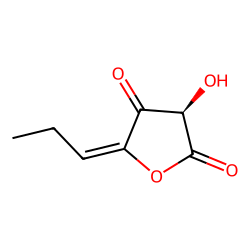
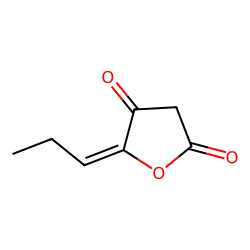
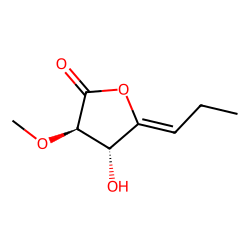
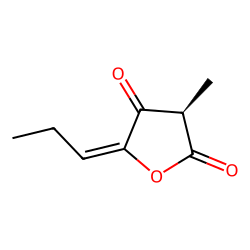
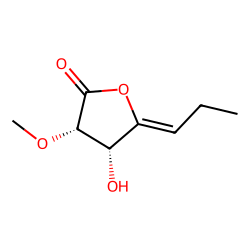
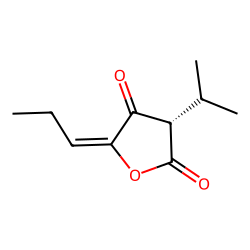
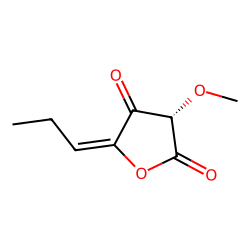
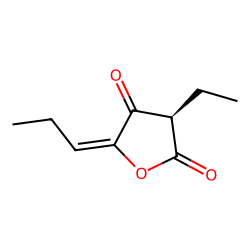
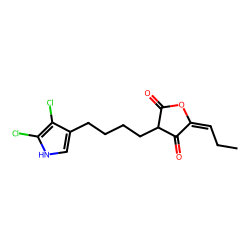
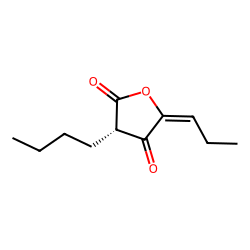
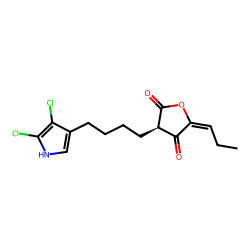
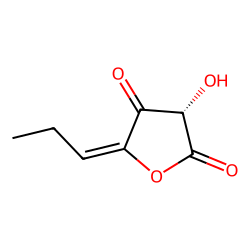
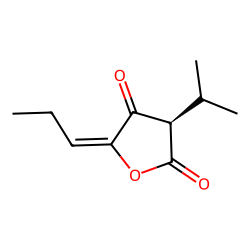
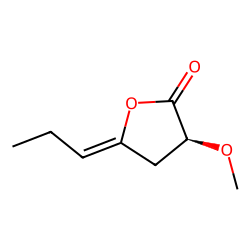
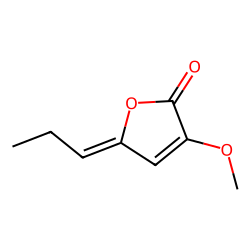
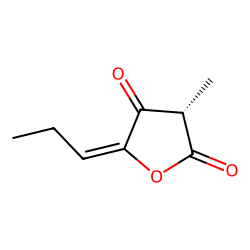
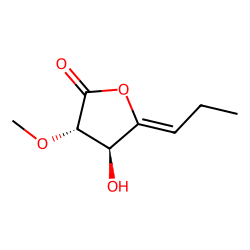
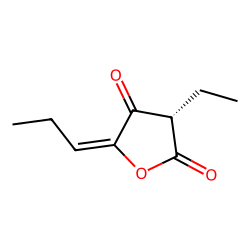
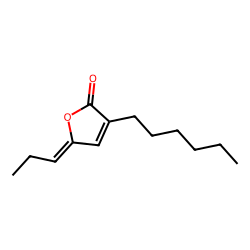
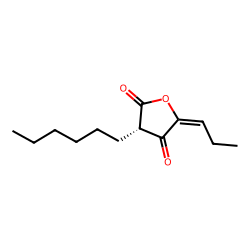
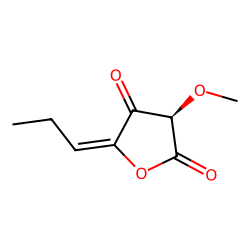
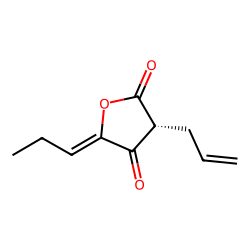
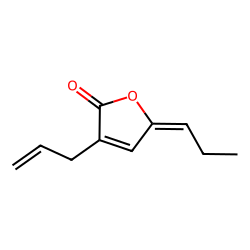
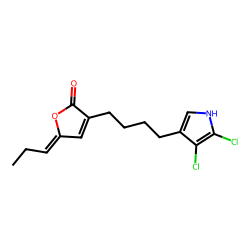
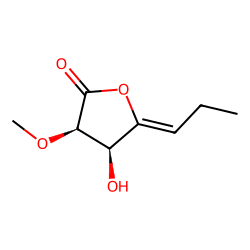
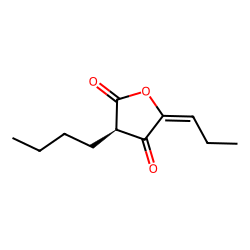
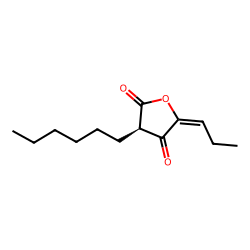
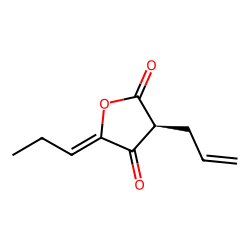
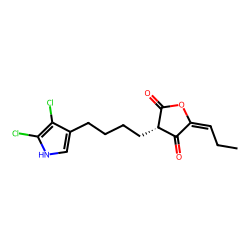
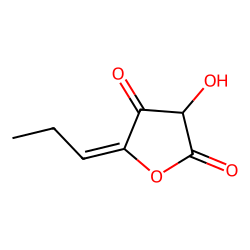
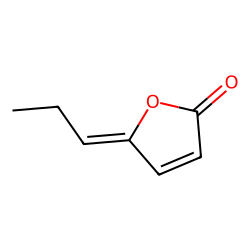
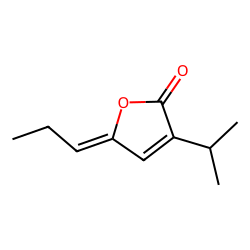
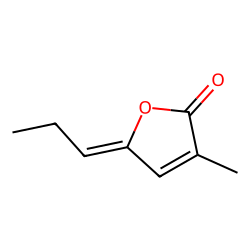
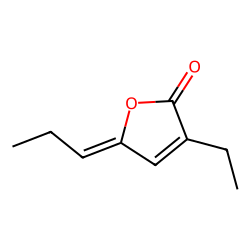
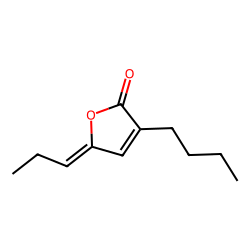
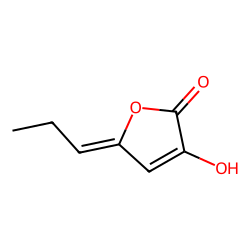
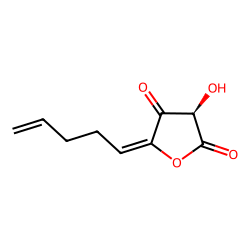
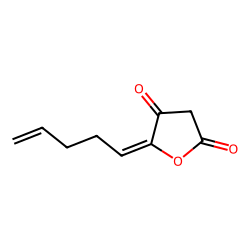
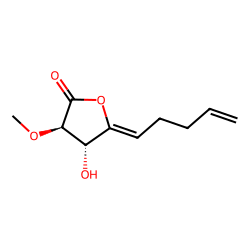
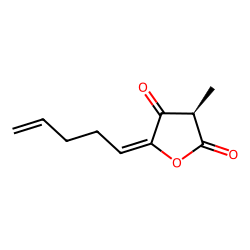
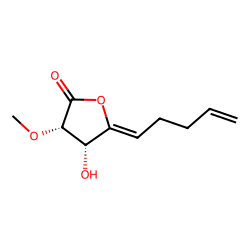
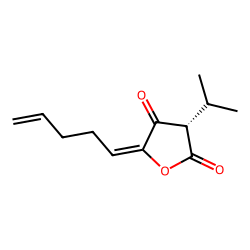
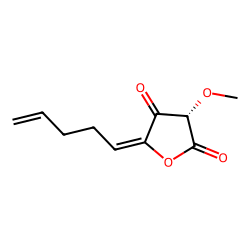
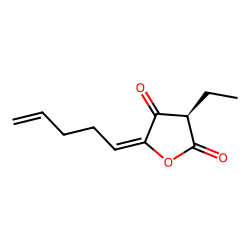
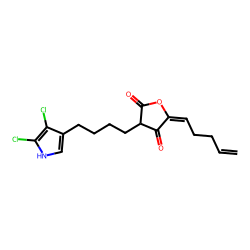
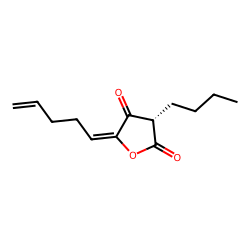
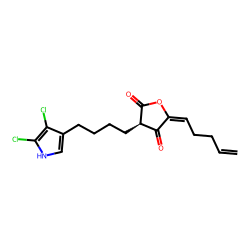
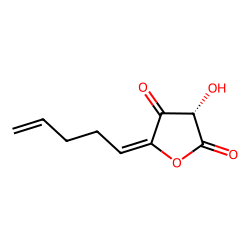
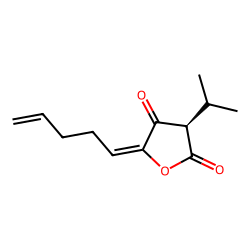
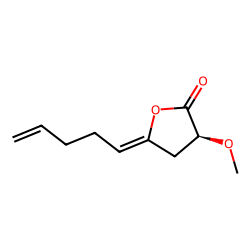
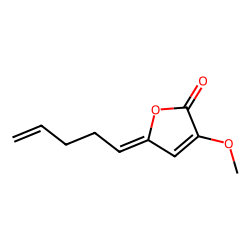
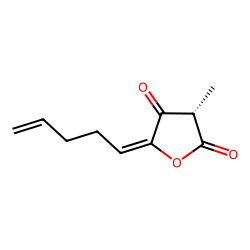
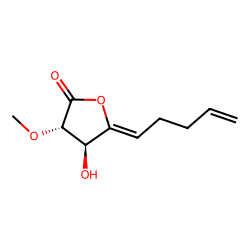
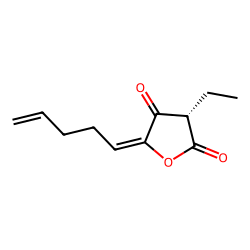
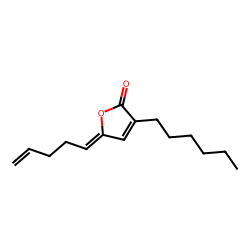
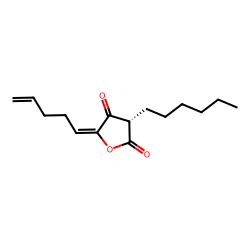
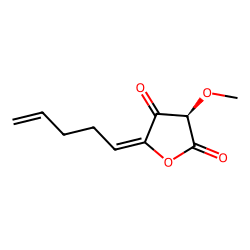
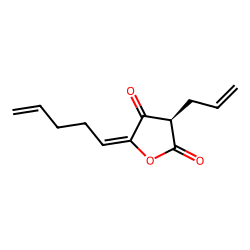
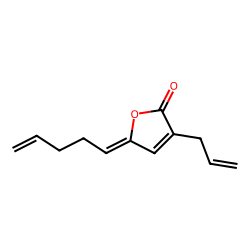
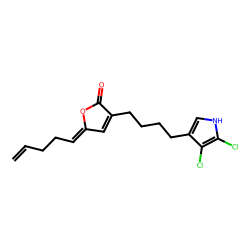
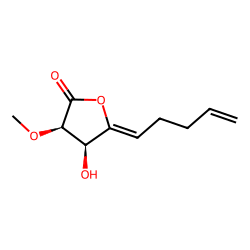
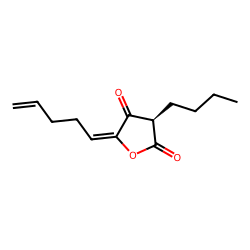
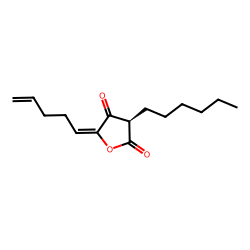
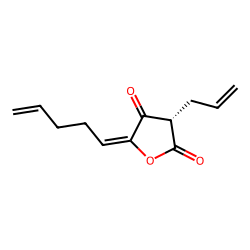
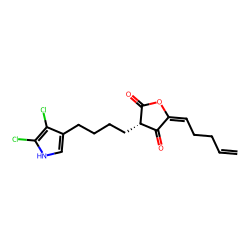
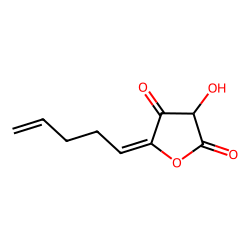
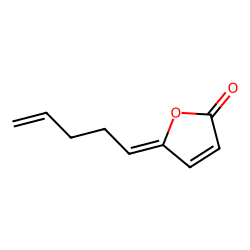
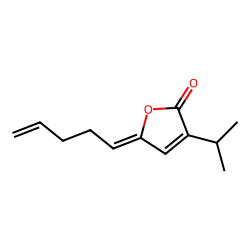
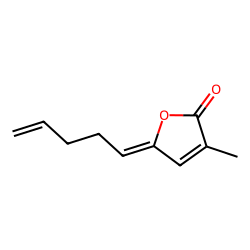
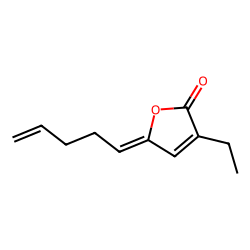
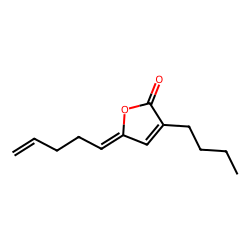
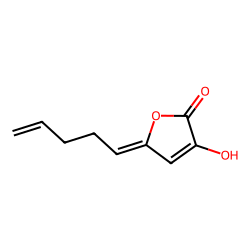
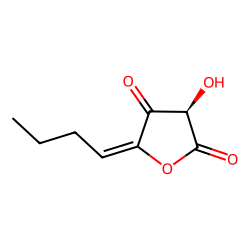
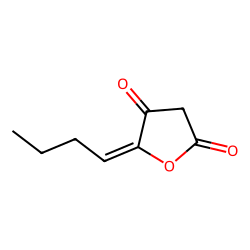
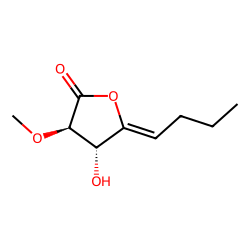
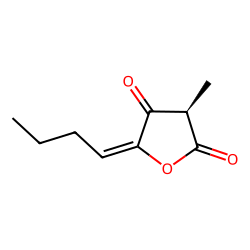
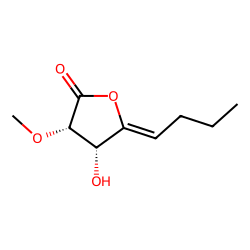
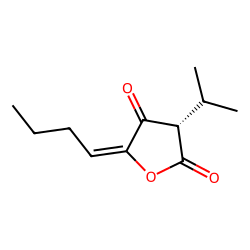
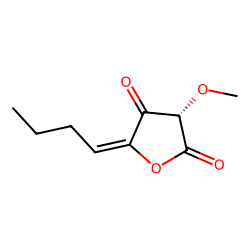
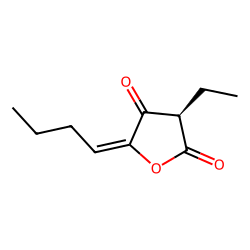
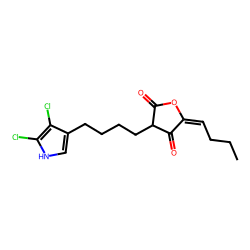
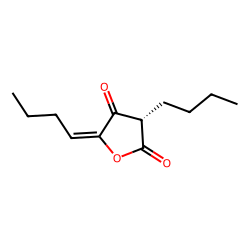
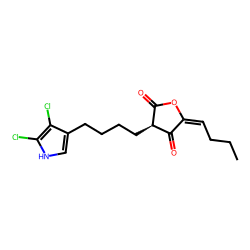
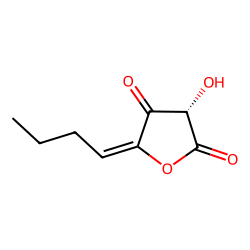
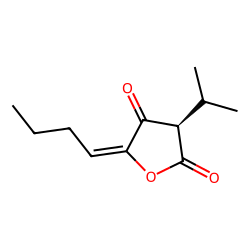
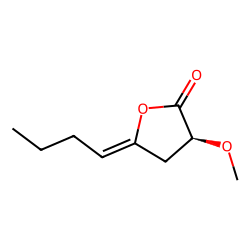
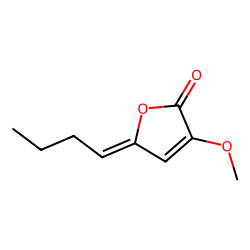
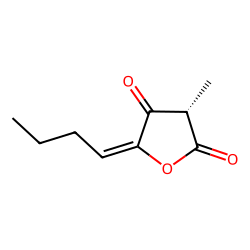
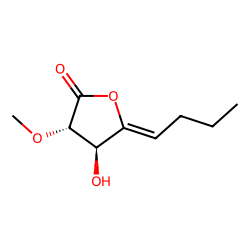
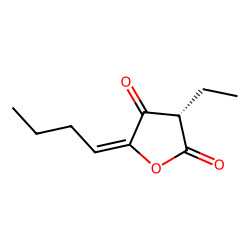
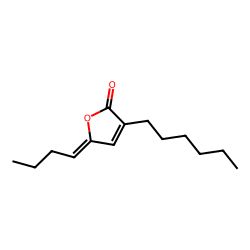
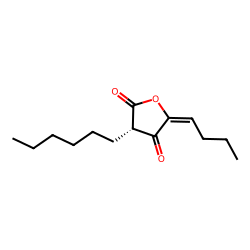
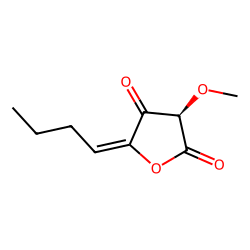
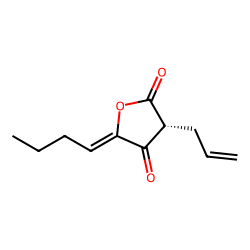
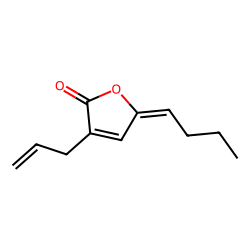
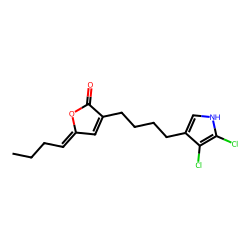
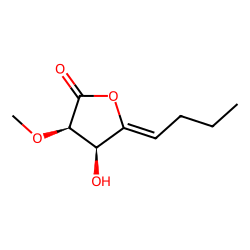
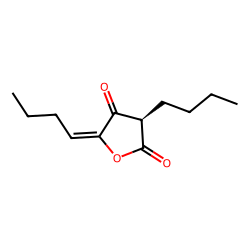
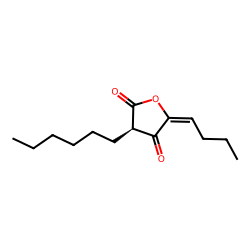
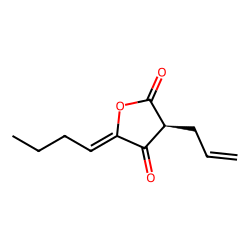
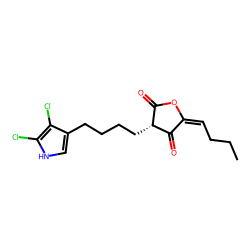
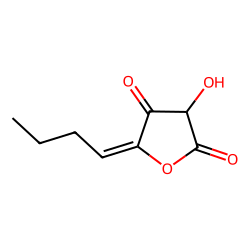
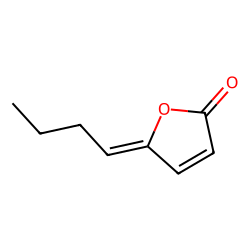
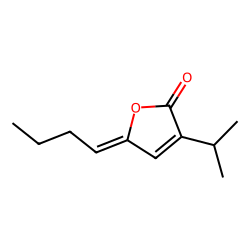
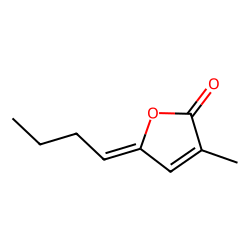
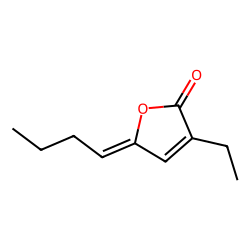
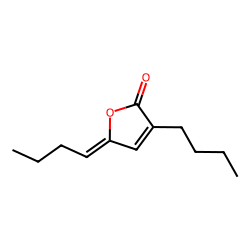
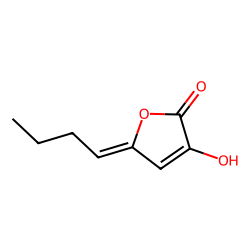
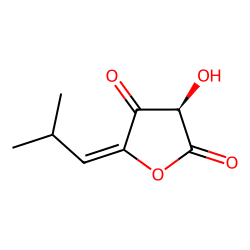
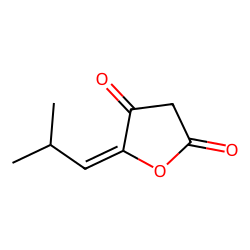
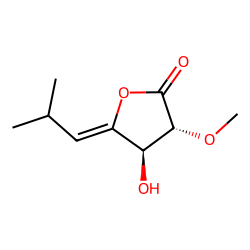
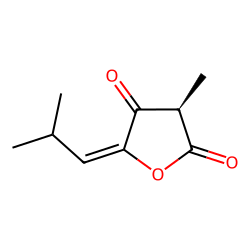
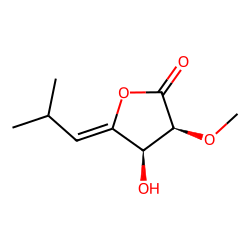
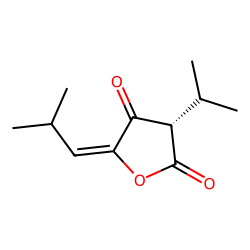
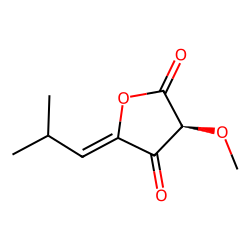
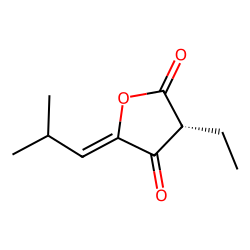
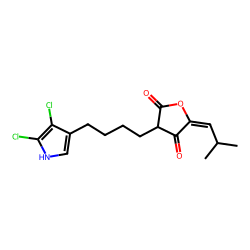
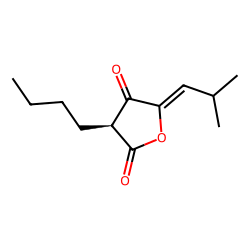
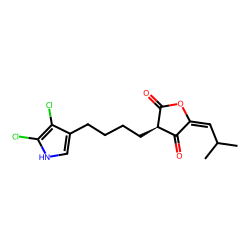
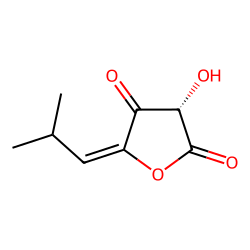
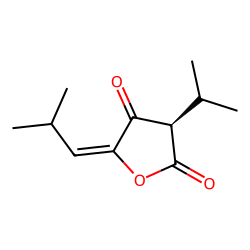
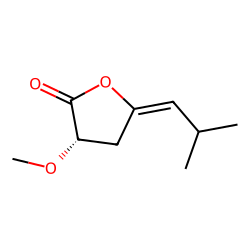
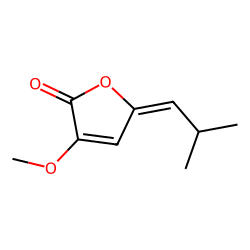
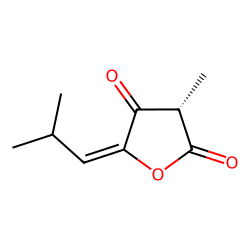
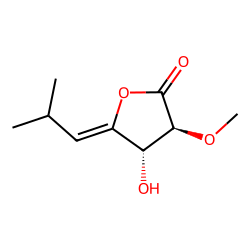
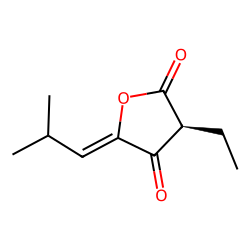
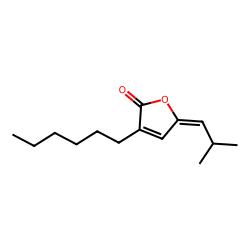
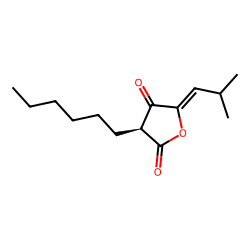
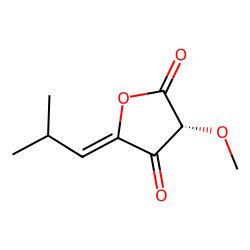
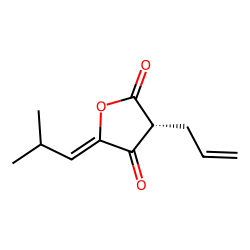
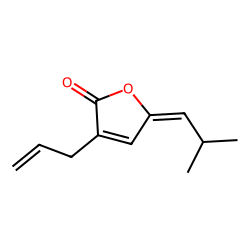
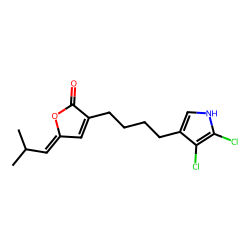
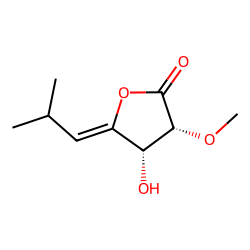
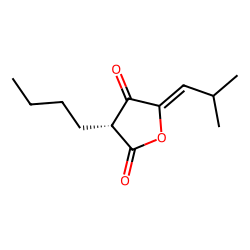
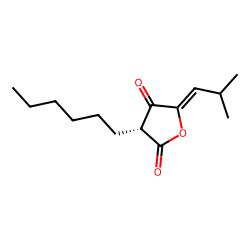
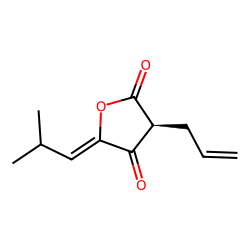
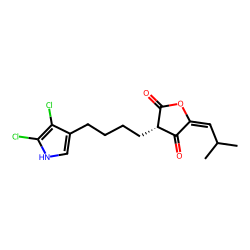
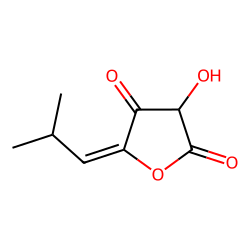
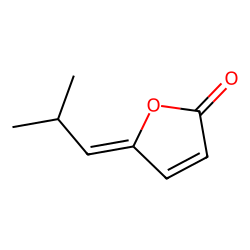
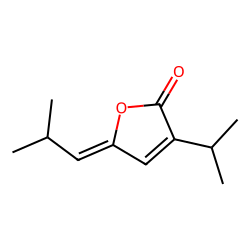
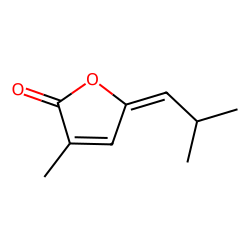
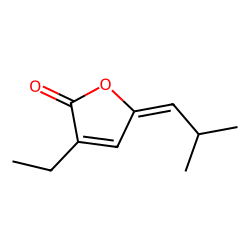
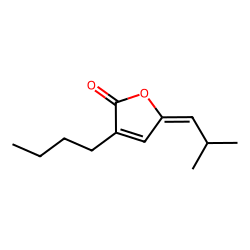
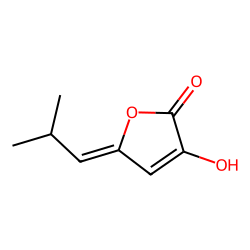
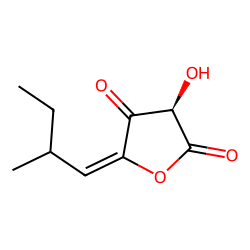
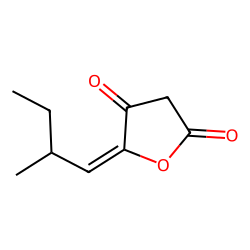
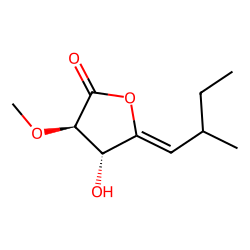
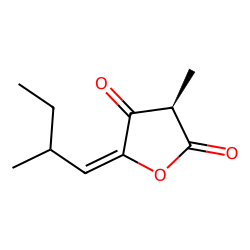
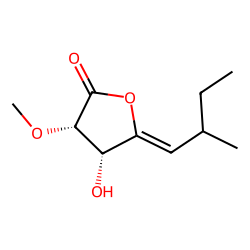
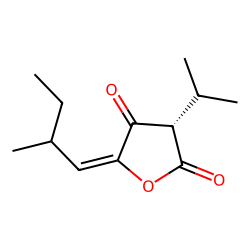
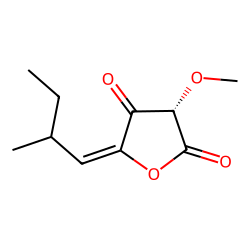
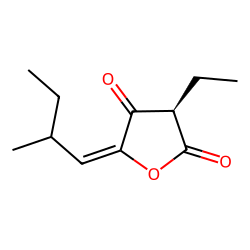
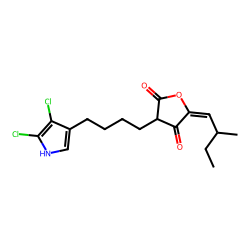
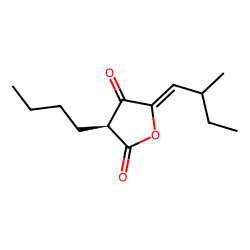
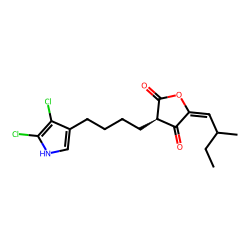
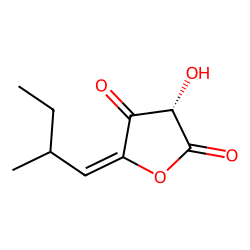
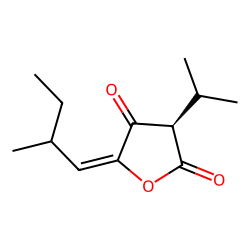
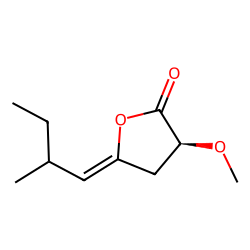
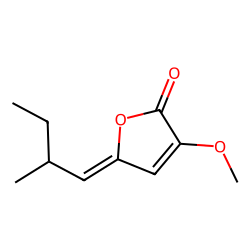
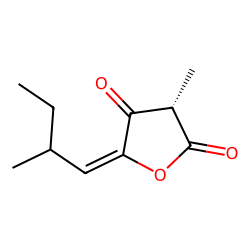
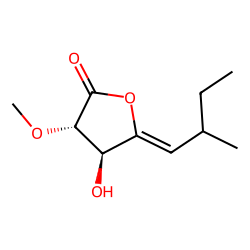
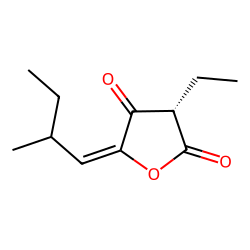
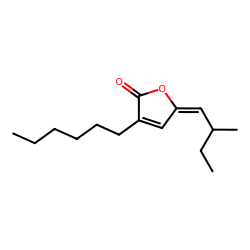
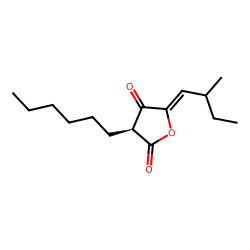
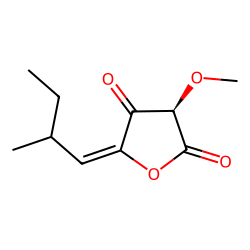
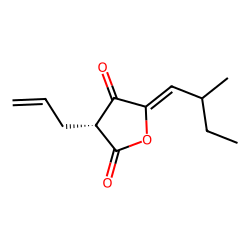
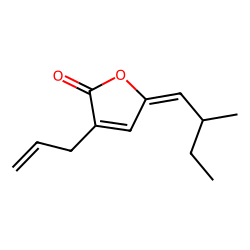
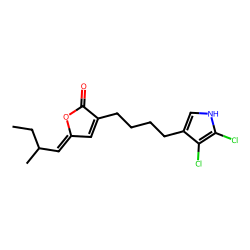
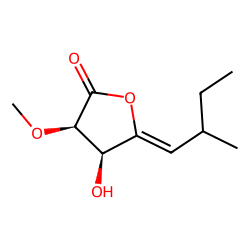
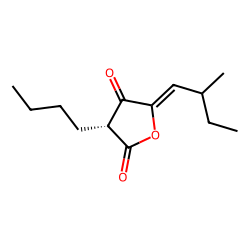
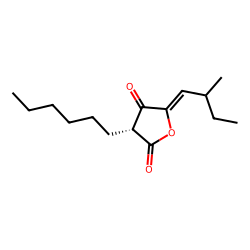
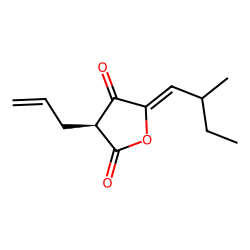
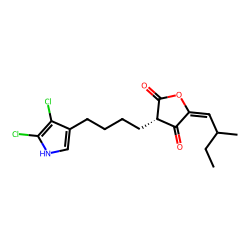
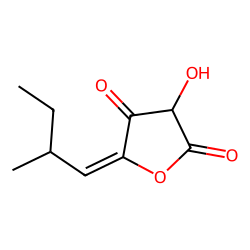
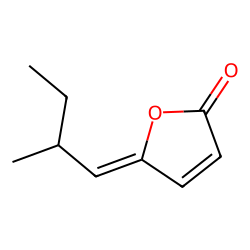
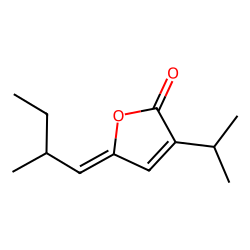
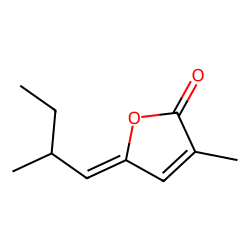
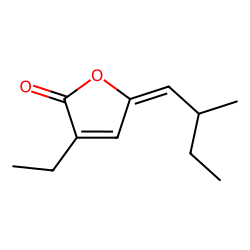
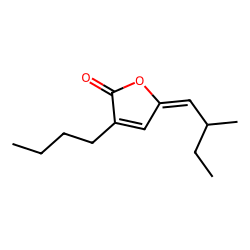
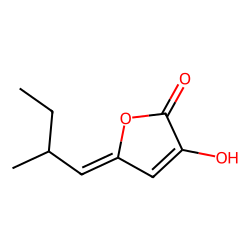
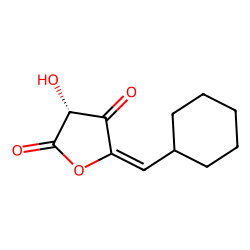
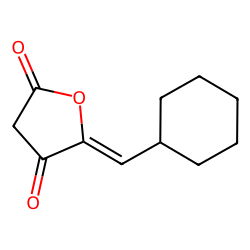
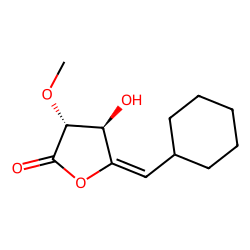
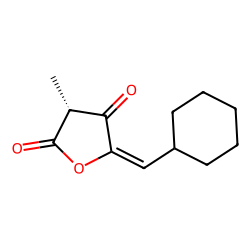
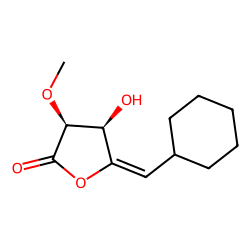
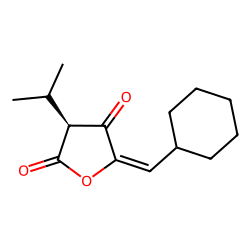
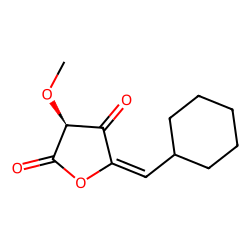
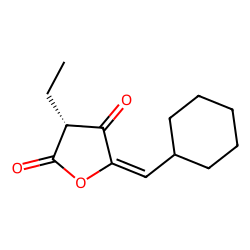
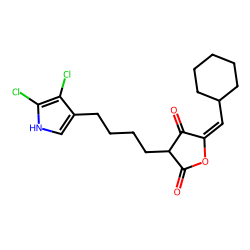
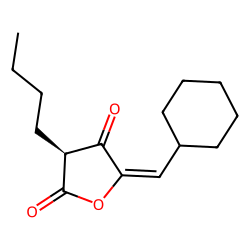
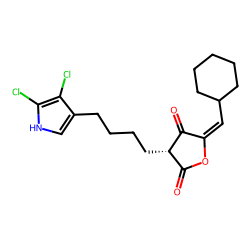
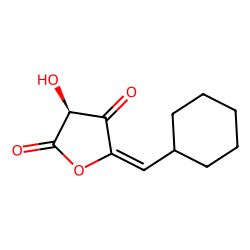
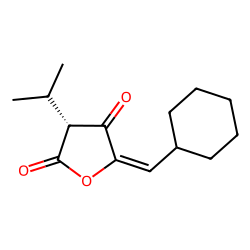
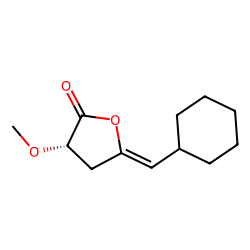
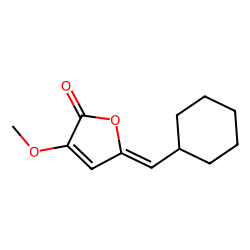
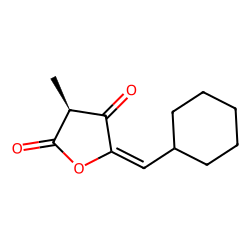
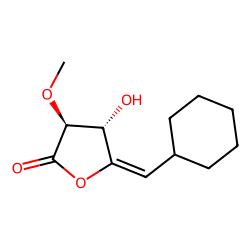
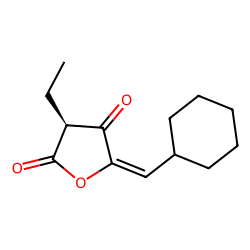
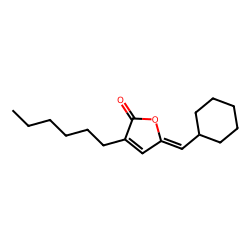
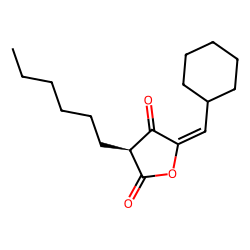
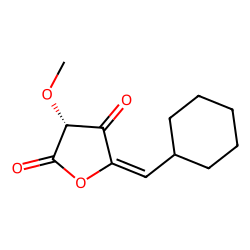
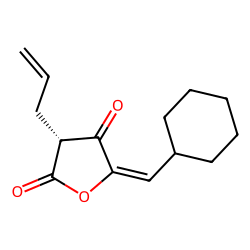
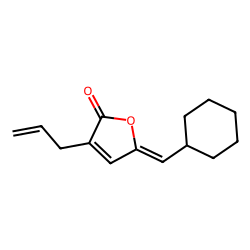
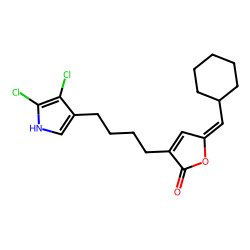
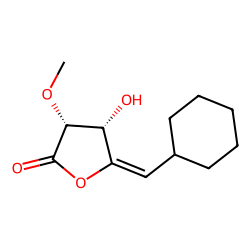
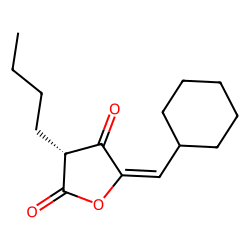
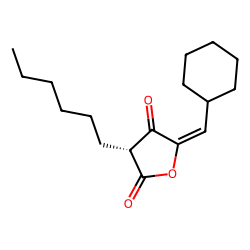
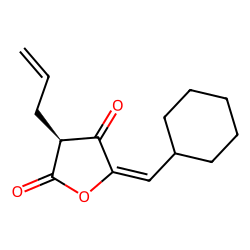
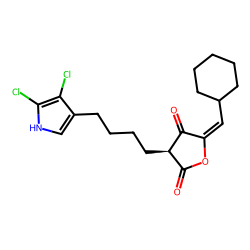
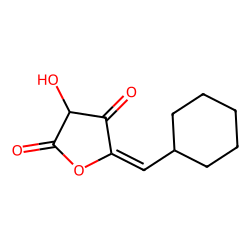
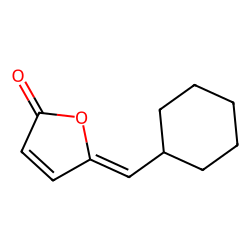
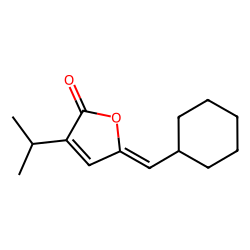
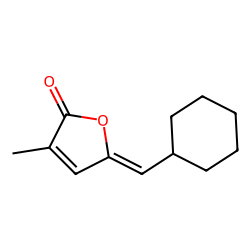
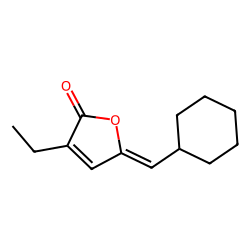
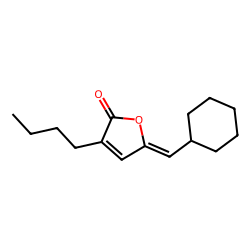
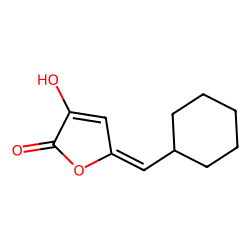
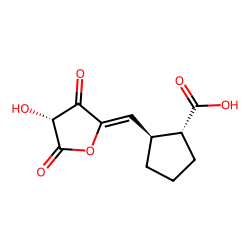
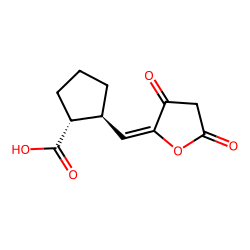
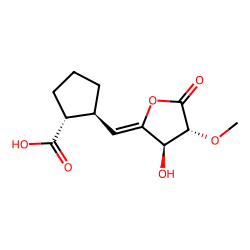
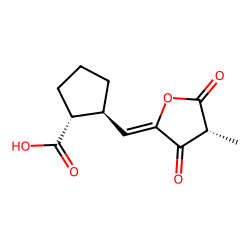
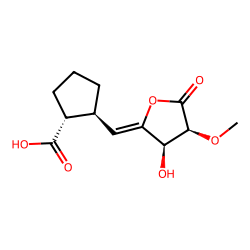
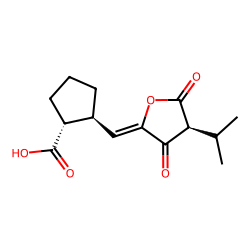
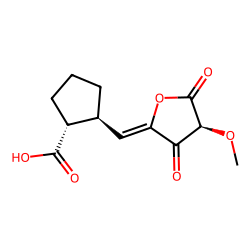
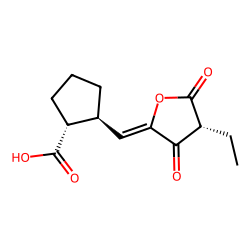
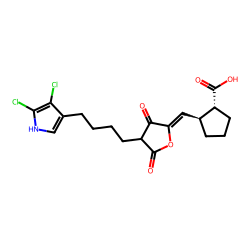
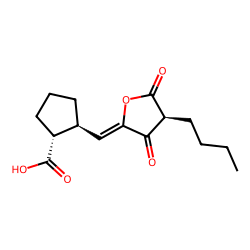
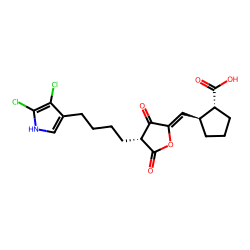
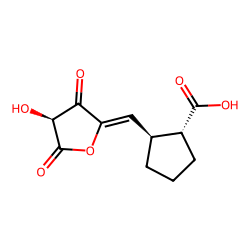
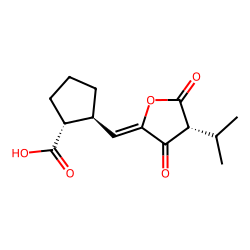
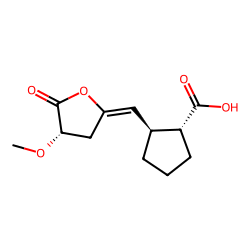
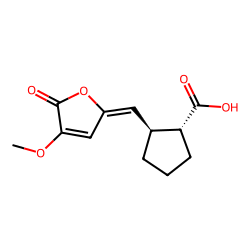
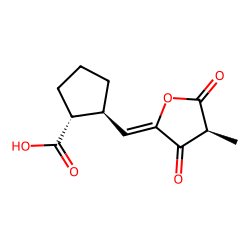
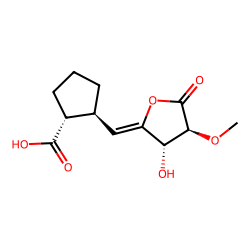
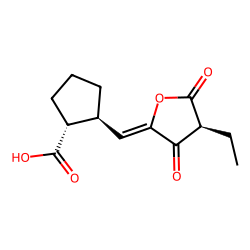
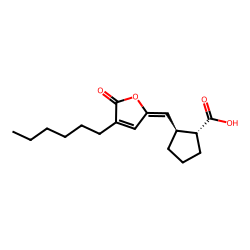
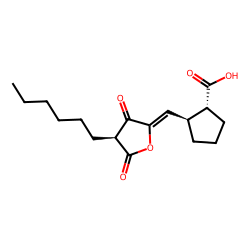
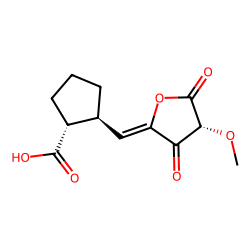
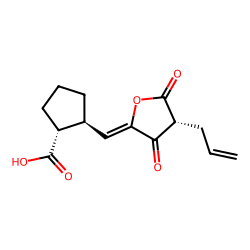
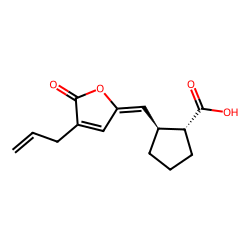
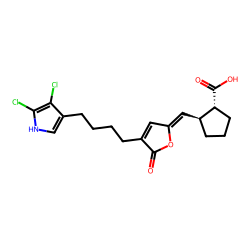
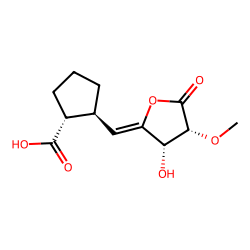
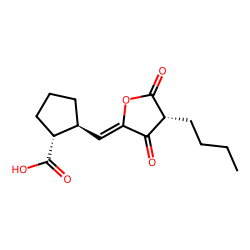
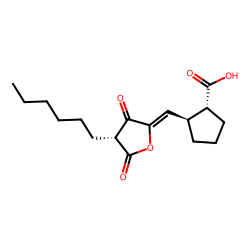
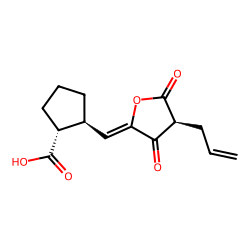
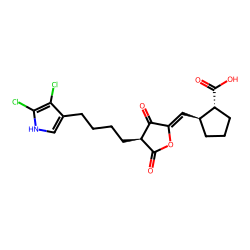
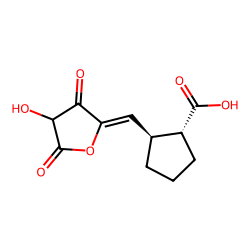
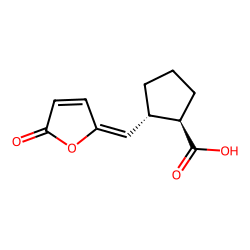
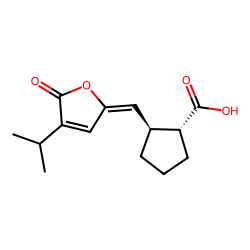
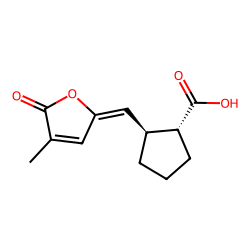
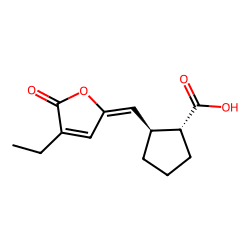
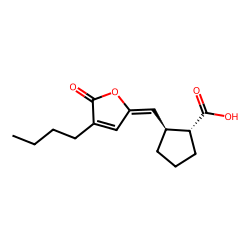
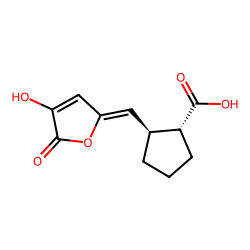
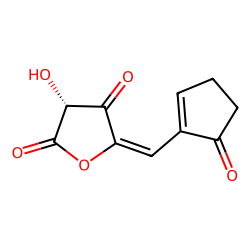
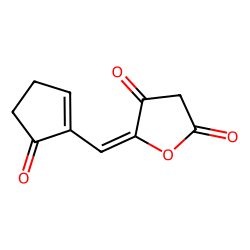
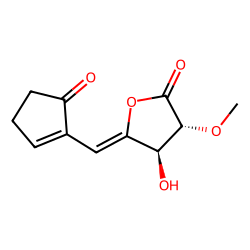
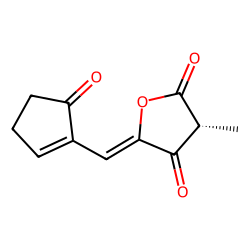
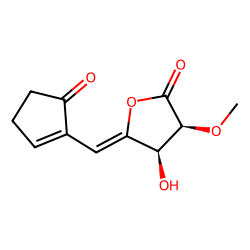
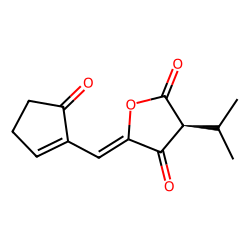
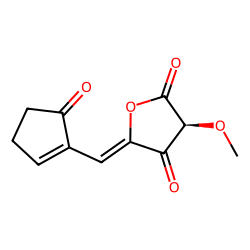
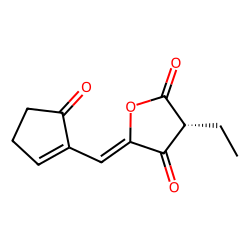
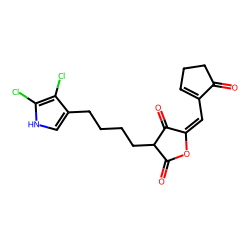
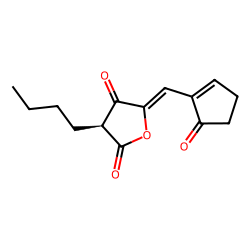
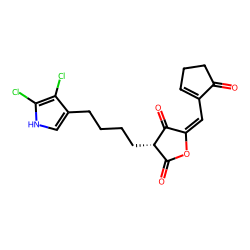
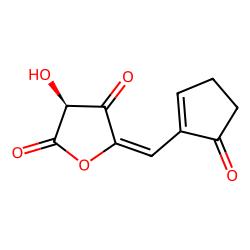
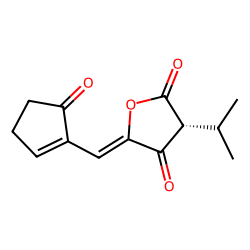
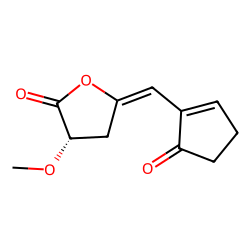
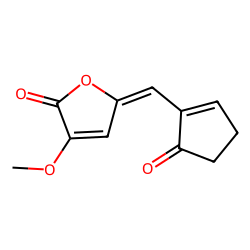
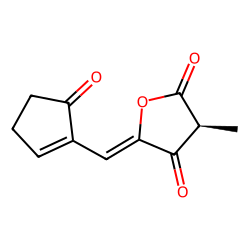
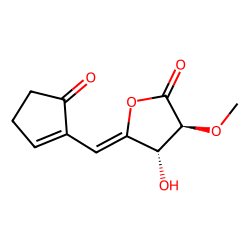
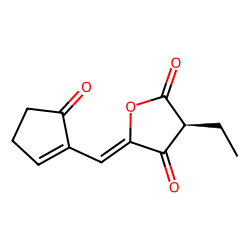
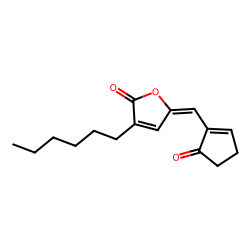
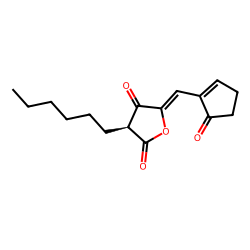
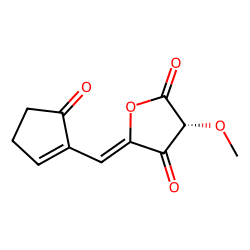
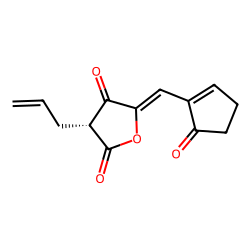
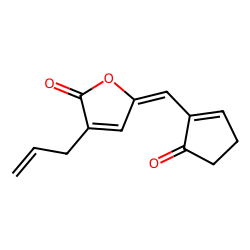
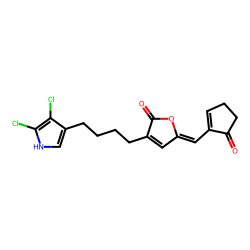
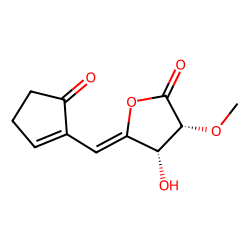
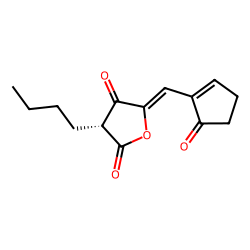
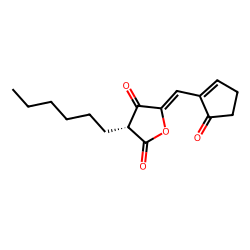
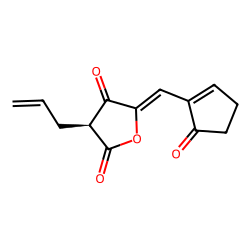
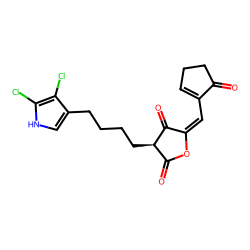
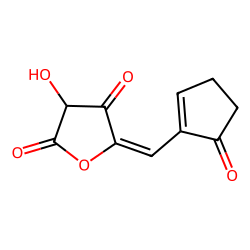
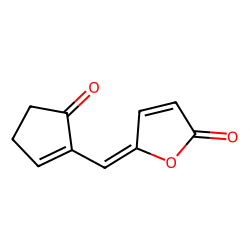
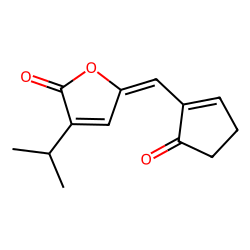
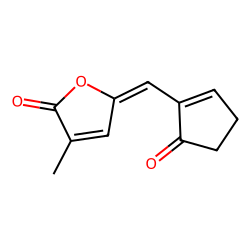
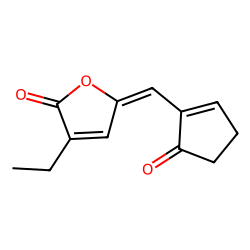
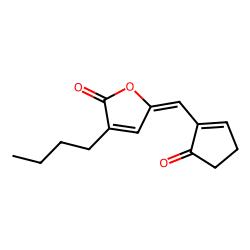
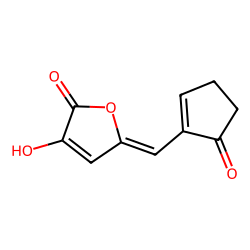
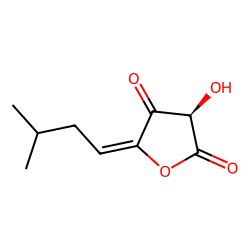
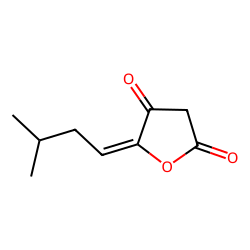
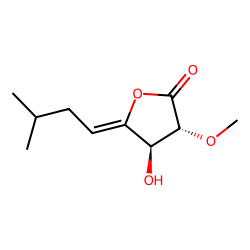
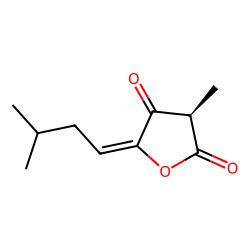
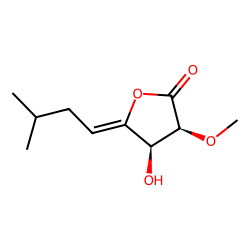
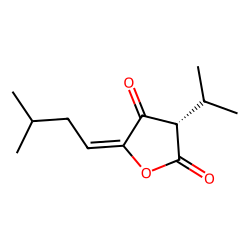
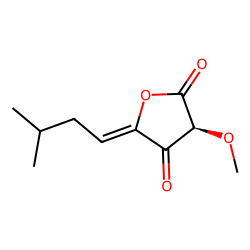
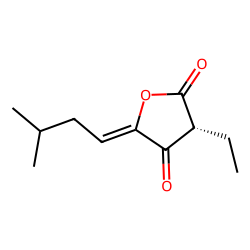
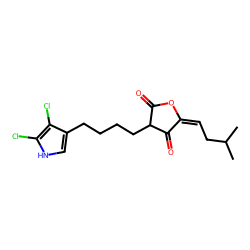
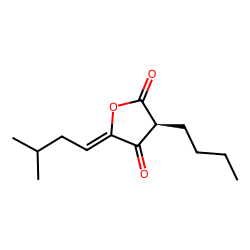
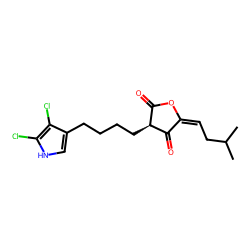
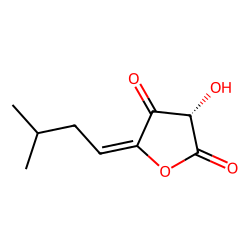
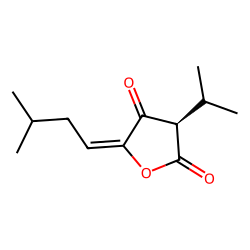
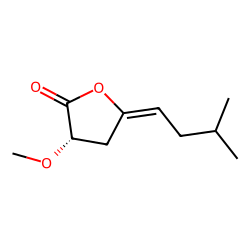
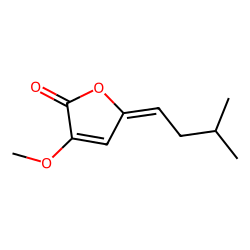
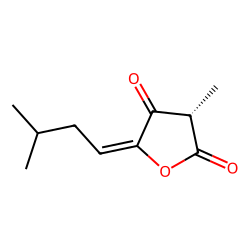
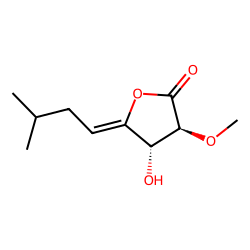
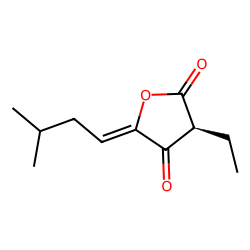
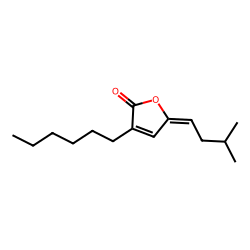
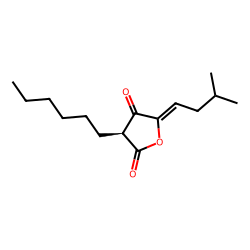
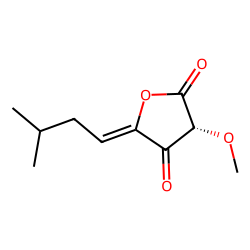
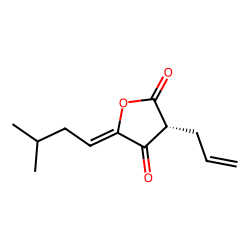
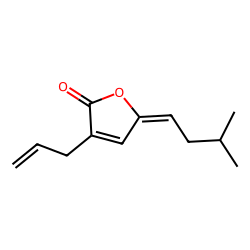
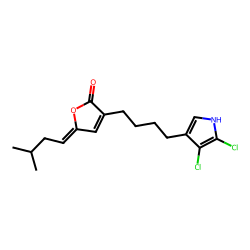
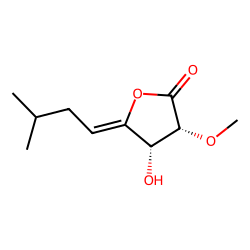
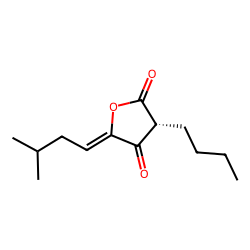
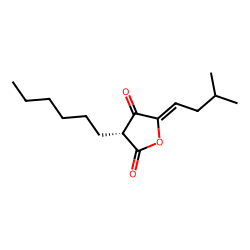
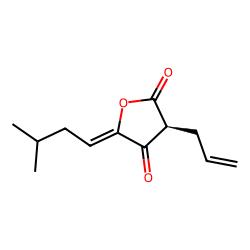
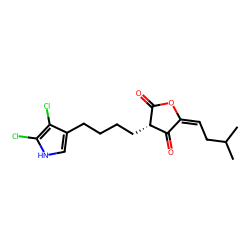
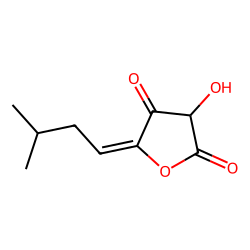
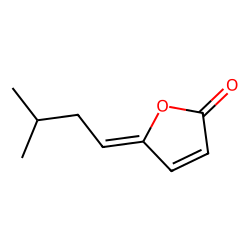
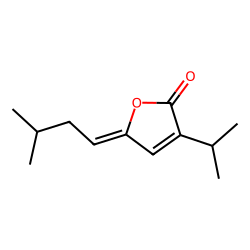
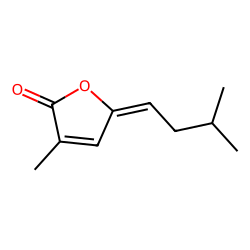
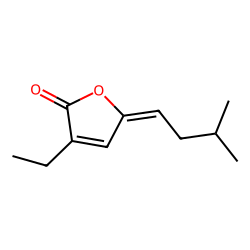
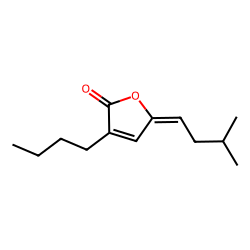
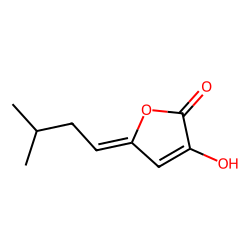
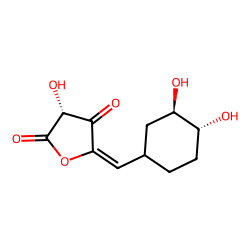
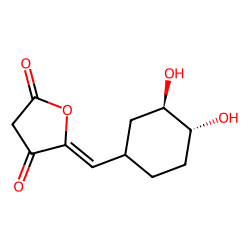
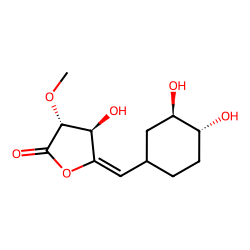
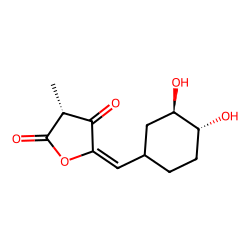
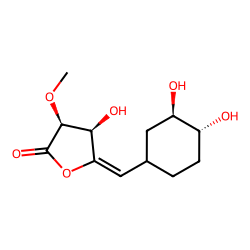
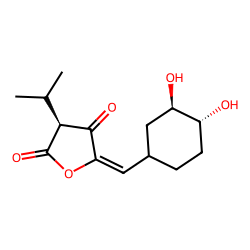
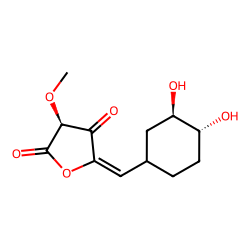
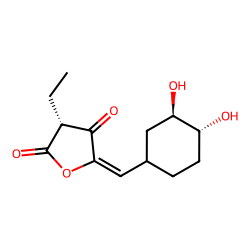
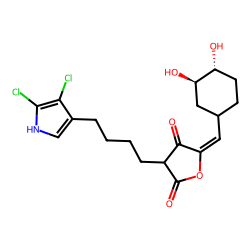
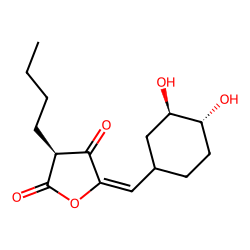
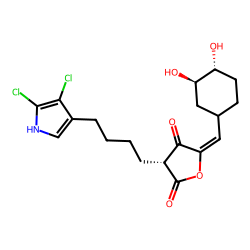
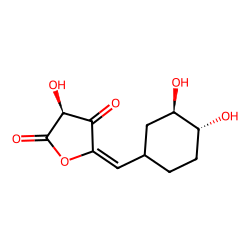
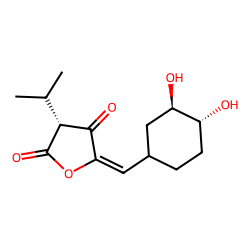
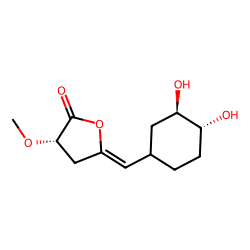
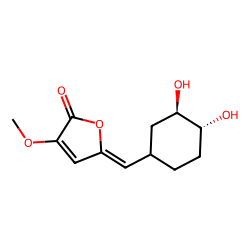
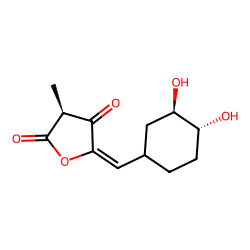
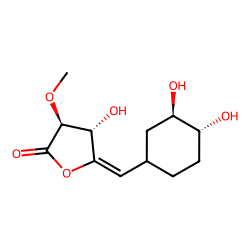
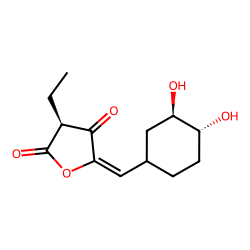
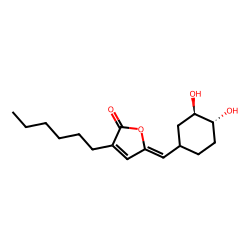
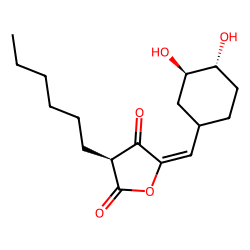
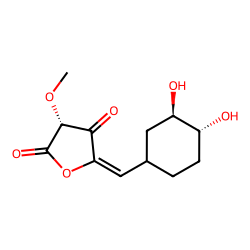
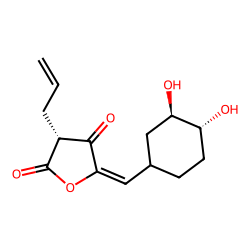
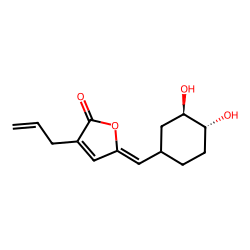
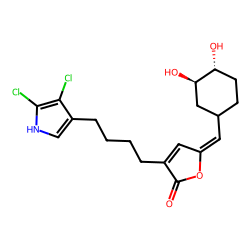
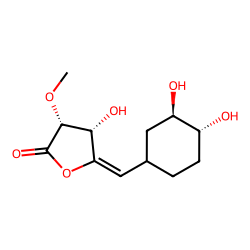
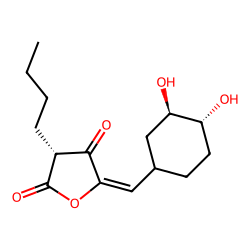
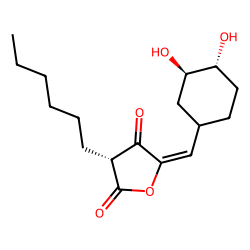
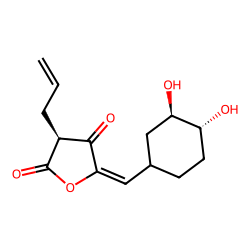
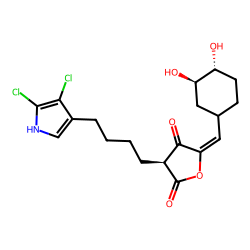
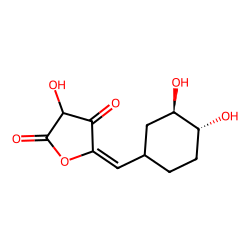
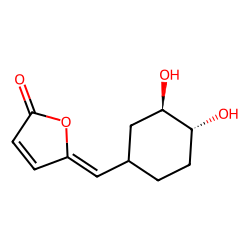
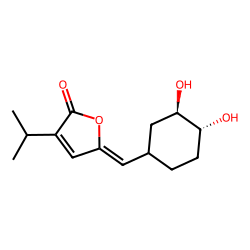
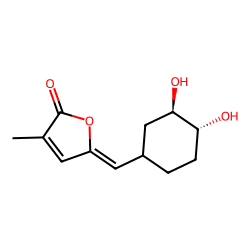
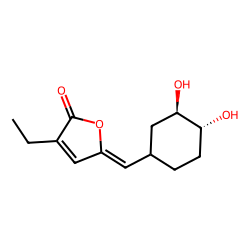
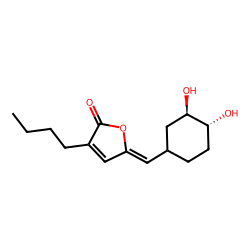
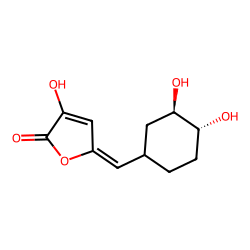
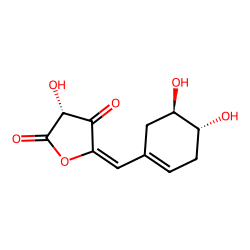
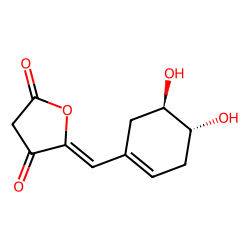
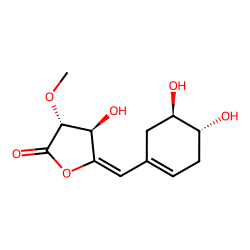
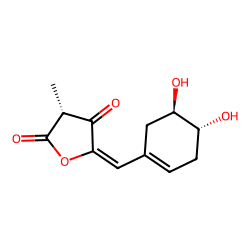
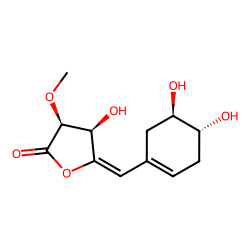
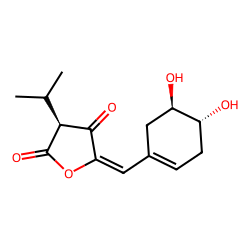
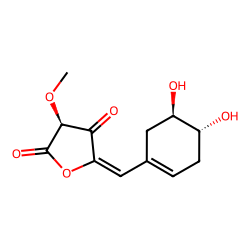
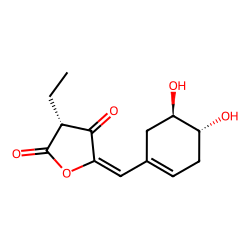
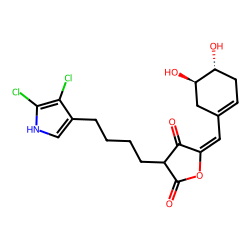
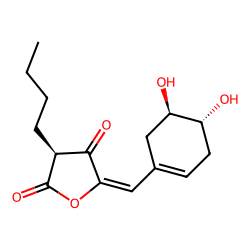
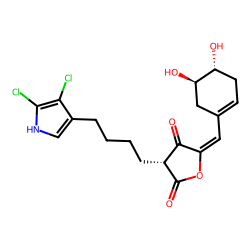
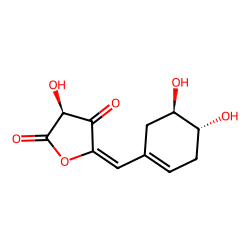
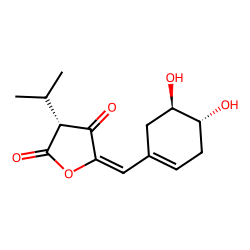
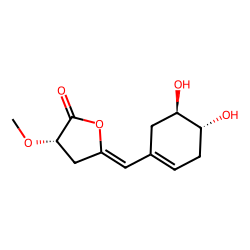
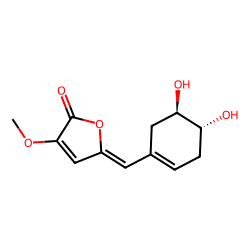
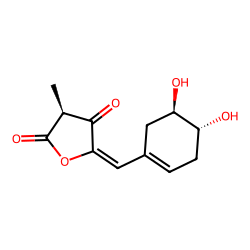
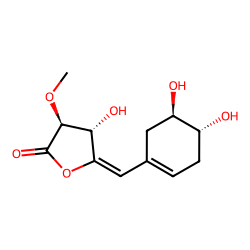
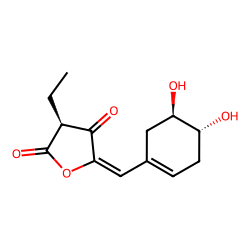
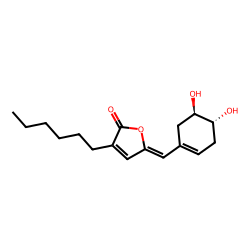
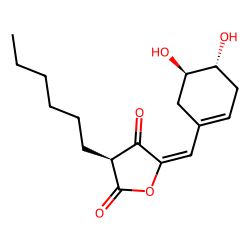
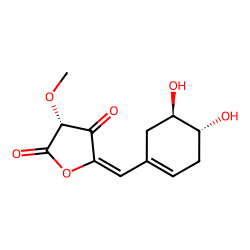
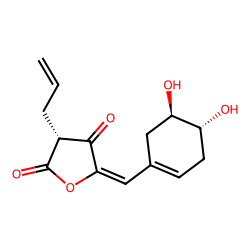
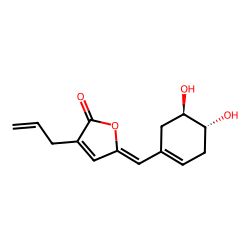
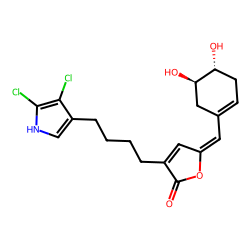
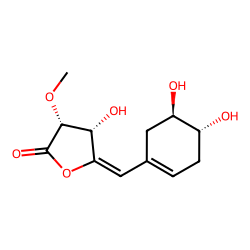
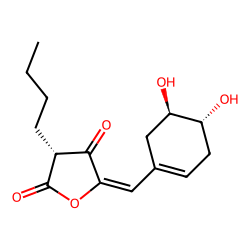
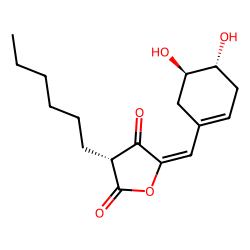
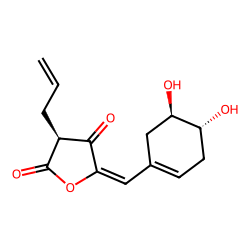
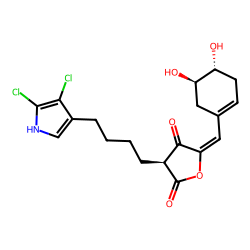
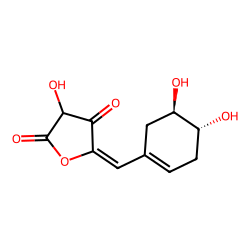
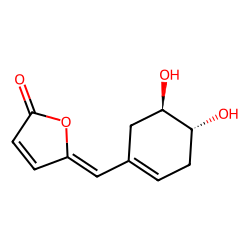
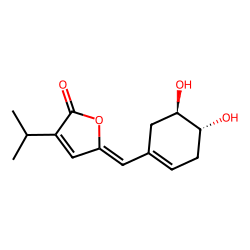
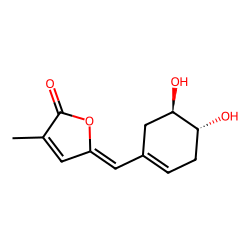
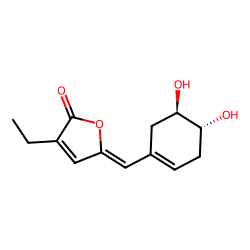
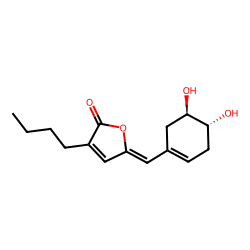
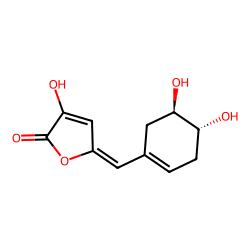
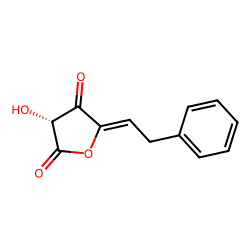
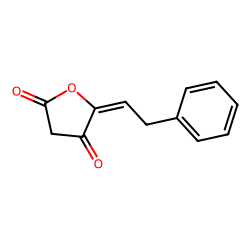
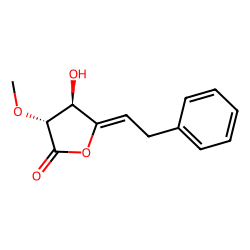
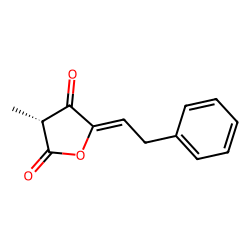
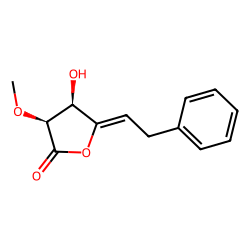
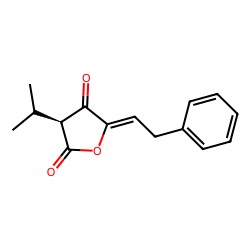
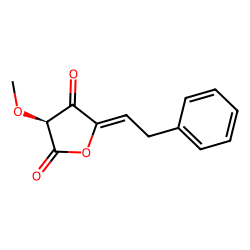
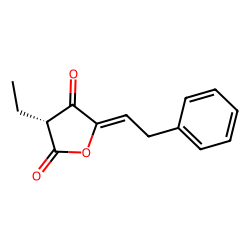
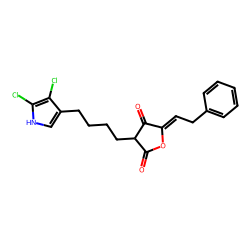
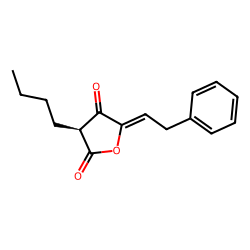
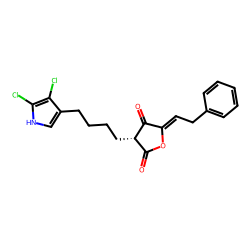
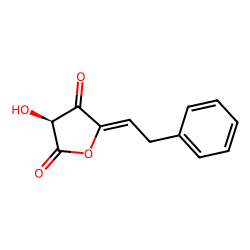
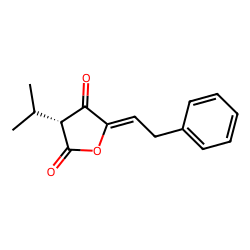
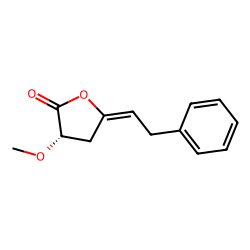
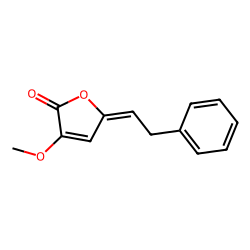
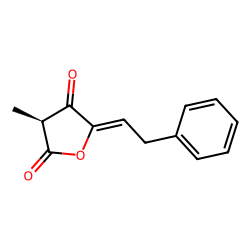
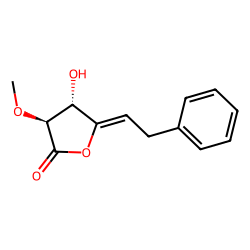
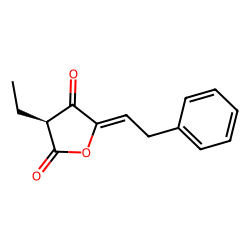
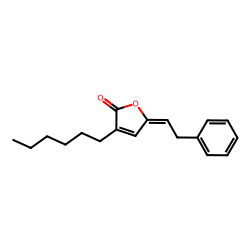
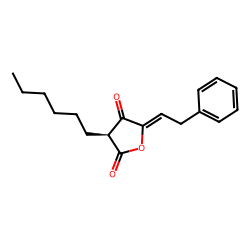
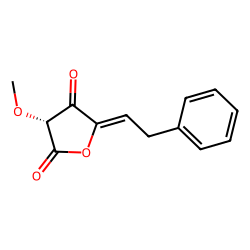
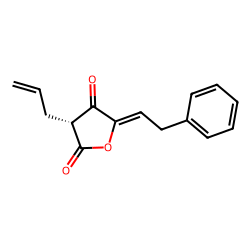
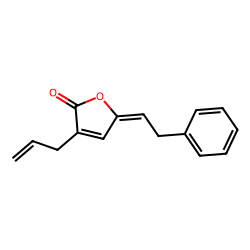
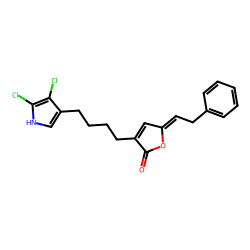
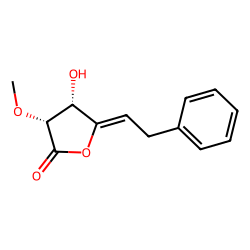
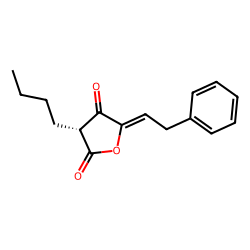
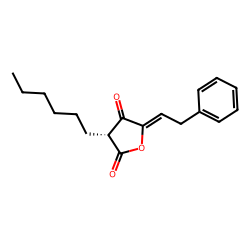
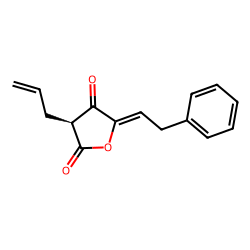
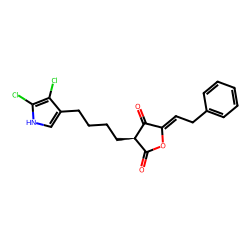
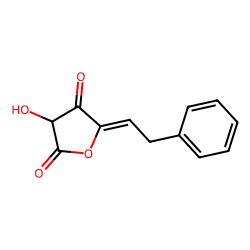
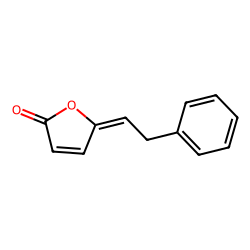
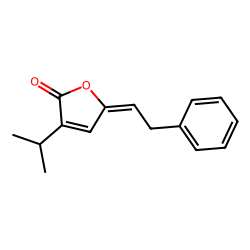
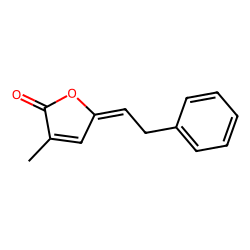
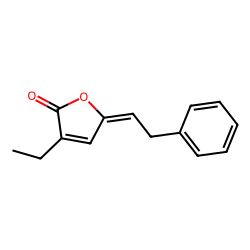
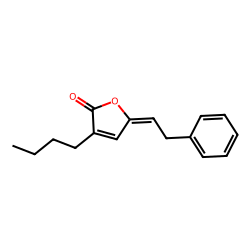
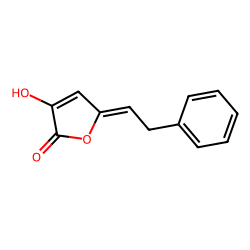
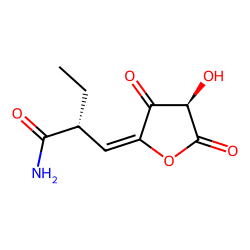
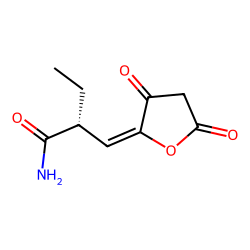
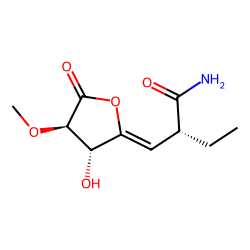
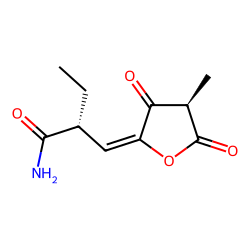
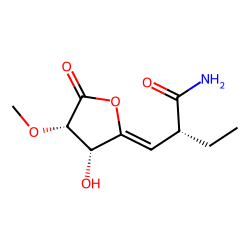
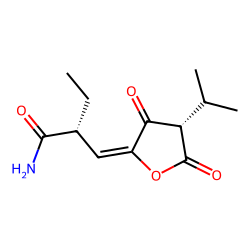
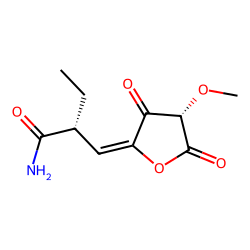
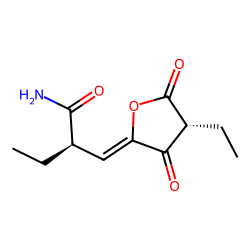
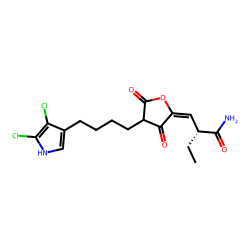
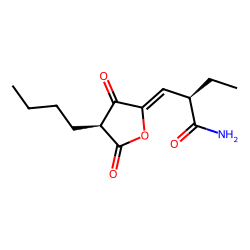
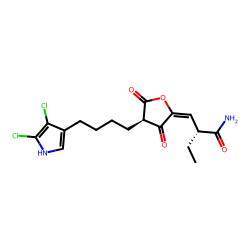
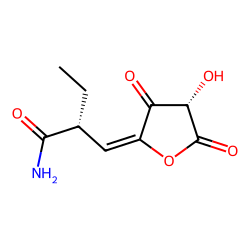
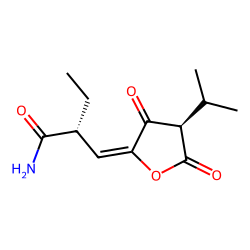
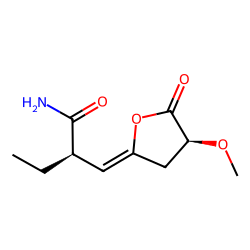
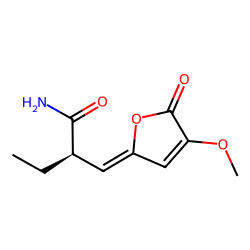
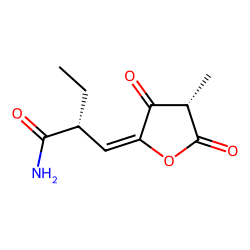
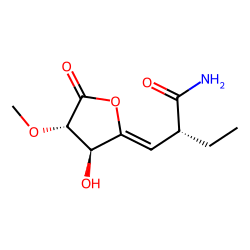
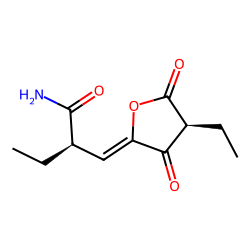
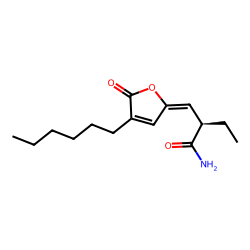
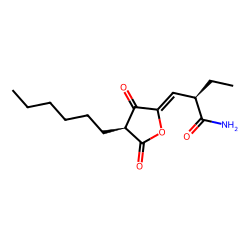
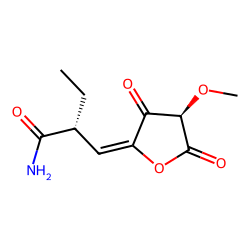
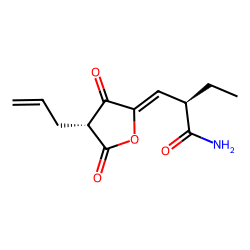
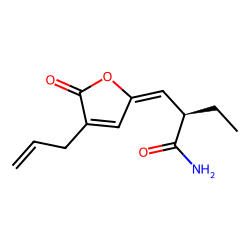
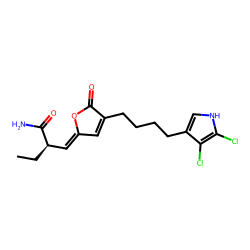
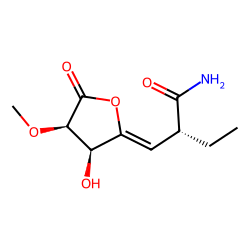
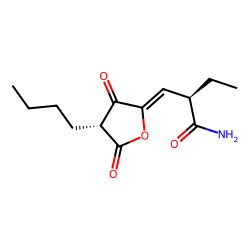
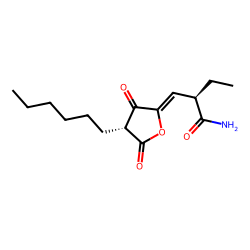
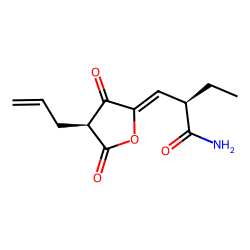
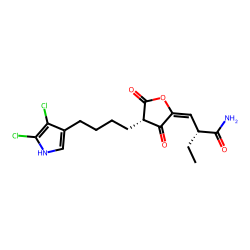
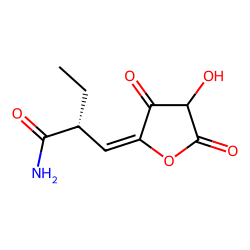
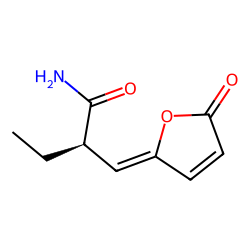
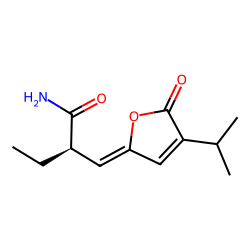
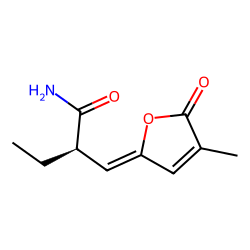
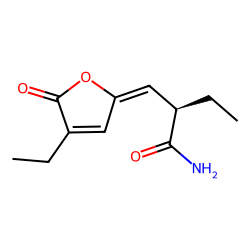
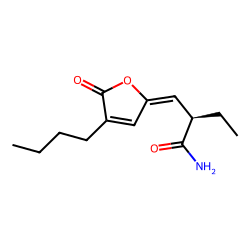
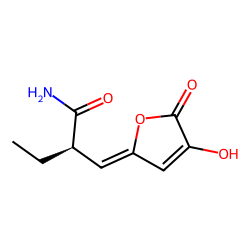
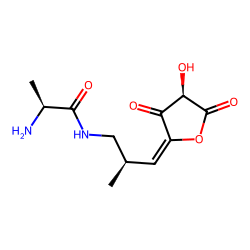
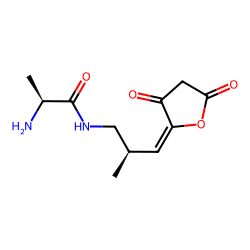
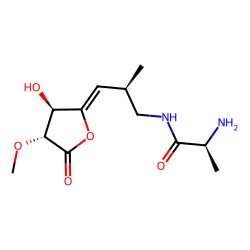
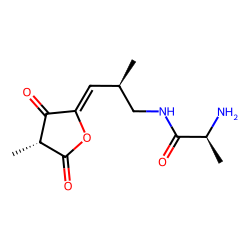
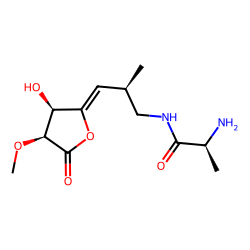
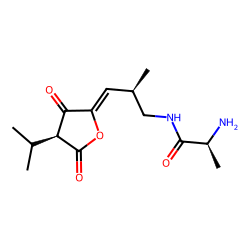
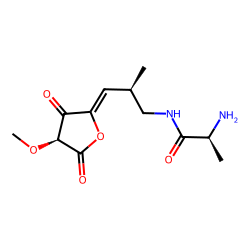
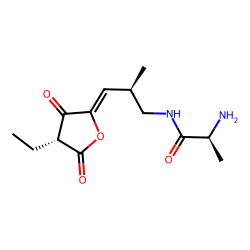
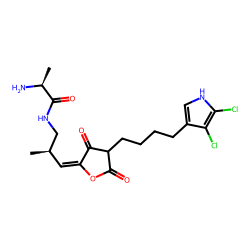
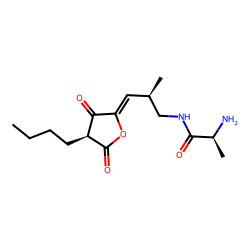
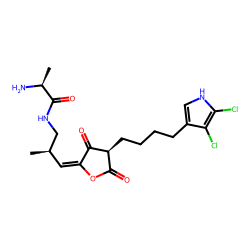
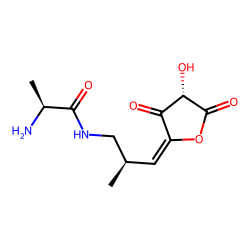
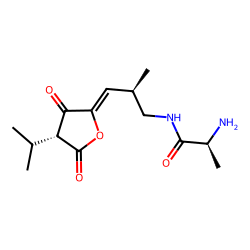
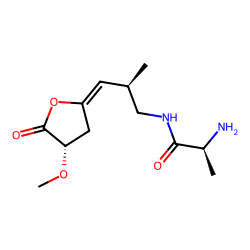
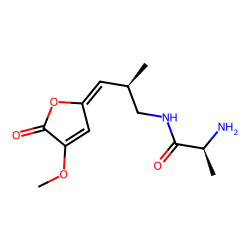
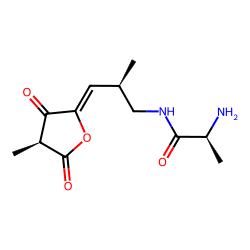
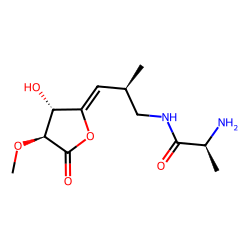
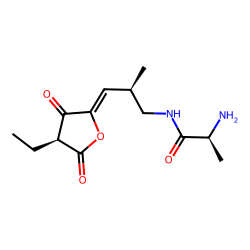
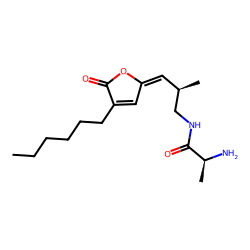
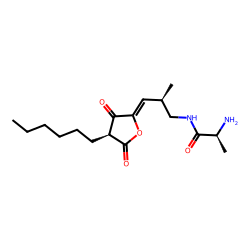
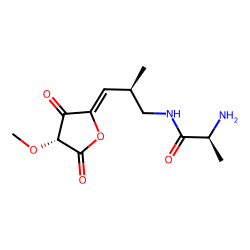
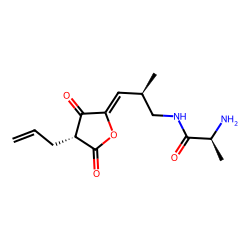
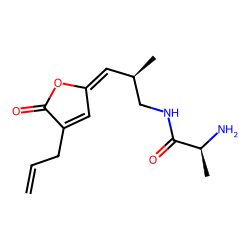
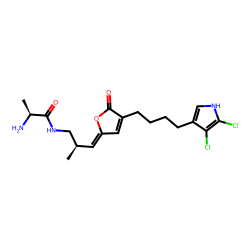
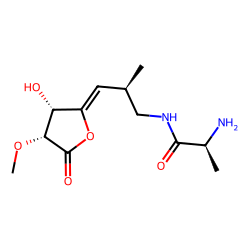
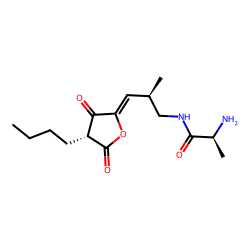
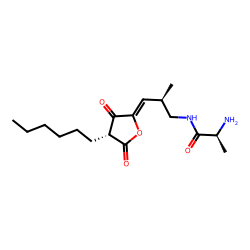
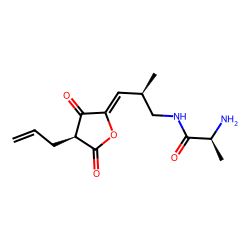
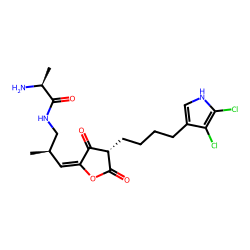
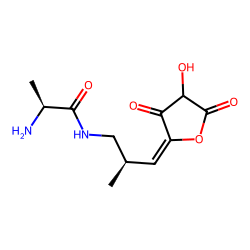
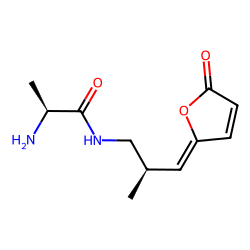
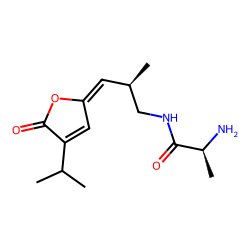
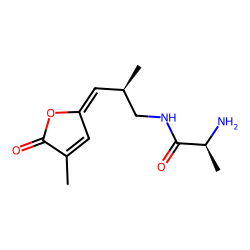
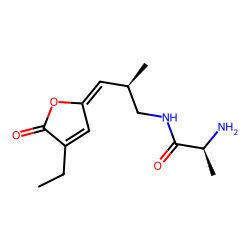
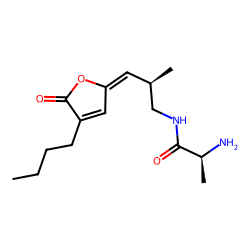
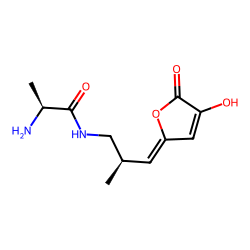

In [65]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, HTML
import pandas as pd
from io import BytesIO
import base64

def mol_to_img_html(smiles, size=(250, 250)):
    """
    Convert SMILES to an HTML img tag with embedded base64 image.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "Invalid SMILES"
    
    img = Draw.MolToImage(mol, size=size)
    
    # Convert image to base64
    buffered = BytesIO()
    img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    
    return f'<img src="data:image/png;base64,{img_str}" width="{size[0]}" height="{size[1]}">'


# Create a subset DataFrame for visualization
moleculesDF_display = generated_molecules_diverseStarterSecondExtensionSMILES[
    generated_molecules_diverseStarterSecondExtensionSMILES['has_target_substructure'] == True
].copy()
# Add structure images as HTML
moleculesDF_display['Structure'] = moleculesDF_display['Canonical_SMILES'].apply(mol_to_img_html)

# Select columns to display
columns_to_show = ['Canonical_SMILES', 'Structure', 'starter_mod', 'secondExtension_mod', 'release_mod', 'Molecular_Weight']
moleculesDF_display = moleculesDF_display[columns_to_show]

# Display as HTML table with images
display(HTML(moleculesDF_display.to_html(escape=False)))

### USE TARGET `SMILES patterns + SMART motiffs`

In [22]:
%%time

from rdkit import Chem
from rdkit.Chem import Descriptors
from collections import OrderedDict
from collections import defaultdict
import pandas as pd

# Define the target substructures to preserve
# These are the lactone ring patterns you want to keep
TARGET_SUBSTRUCTURES = [
    'CCC=C1C[C@H](OC)C(=O)O1',  # First pattern
    'CCC=C1C=CC(=O)O1',         # Second pattern
]

# Convert to RDKit mol objects and create SMARTS patterns
target_mols = []
target_smarts = []

for smiles in TARGET_SUBSTRUCTURES:
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        target_mols.append(mol)
        # Also create a more flexible SMARTS pattern from the core lactone
        target_smarts.append(Chem.MolFromSmiles(smiles))

# Define core lactone SMARTS patterns (more flexible matching)
# 5-membered lactone with double bond: C=CC(=O)O in a ring
LACTONE_SMARTS_PATTERNS = [
    '[#6]C=C1C[C@@H]([#6])C(=O)O1',   # Pattern 1 with stereochemistry
    '[#6]C=C1C[C@H]([#6])C(=O)O1',    # Pattern 1 with opposite stereochemistry
    '[#6]C=C1CC([#6])C(=O)O1',        # Pattern 1 without stereochemistry
    '[#6]C=C1C=CC(=O)O1',             # Pattern 2: unsaturated lactone
    'C=C1CC(*)C(=O)O1',               # Generic 5-membered lactone with double bond
    'C=C1C=CC(=O)O1',                 # Generic unsaturated 5-membered lactone
]

# Compile SMARTS patterns
compiled_smarts = []
for smarts in LACTONE_SMARTS_PATTERNS:
    pattern = Chem.MolFromSmarts(smarts)
    if pattern:
        compiled_smarts.append(pattern)

print(f"Loaded {len(target_mols)} target substructure molecules")
print(f"Loaded {len(compiled_smarts)} SMARTS patterns for matching")


def has_target_substructure(mol):
    """
    Check if molecule contains any of the target substructures.
    Returns True if any target substructure is found.
    """
    if mol is None:
        return False
    
    # Check against exact substructure matches
    for target in target_mols:
        if mol.HasSubstructMatch(target):
            return True
    
    # Check against SMARTS patterns
    for pattern in compiled_smarts:
        if mol.HasSubstructMatch(pattern):
            return True
    
    return False


def get_matching_pattern(mol):
    """
    Return which pattern(s) the molecule matches.
    """
    if mol is None:
        return None
    
    matches = []
    
    # Check exact matches
    for i, target in enumerate(target_mols):
        if mol.HasSubstructMatch(target):
            matches.append(f"exact_match_{i+1}")
    
    # Check SMARTS matches
    for i, pattern in enumerate(compiled_smarts):
        if mol.HasSubstructMatch(pattern):
            matches.append(f"smarts_pattern_{i+1}")
    
    return matches if matches else None


# Use separate lists for starters and second extensions
allStarters = allStarterTypes
allSecondExtensions = allModuleTypes

print("\nNumber of unique starter modules:", len(allStarters))
print("Number of unique second extension modules:", len(allSecondExtensions))
print(f"Maximum possible combinations: {len(allStarters)} starters × {len(allSecondExtensions)} second extensions = {len(allStarters) * len(allSecondExtensions)}")

results = []

# Track failures
failure_reasons = {
    'no_product_from_computeProduct': 0,
    'no_final_mol_from_TE': 0,
    'no_matching_substructure': 0,
    'exception_errors': 0
}

# Track release types dynamically
release_counts = defaultdict(int)

# Track substructure matches
substructure_match_counts = defaultdict(int)

print(f"\nCreating diverse molecules with variable starter and module2...")
print(f"Keeping module1 and TE fixed")
print(f"Filtering for target substructures\n")

# Fixed components (module1 and TE only)
AT_domain_mod1 = bcs.AT(active=True, substrate="hmal") 
KR_domain_mod1 = bcs.KR(active=True, type="B1")
DH_domain_mod1 = bcs.DH(active=True)
mod1_domains_dict = OrderedDict({bcs.AT: AT_domain_mod1,
                                 bcs.KR: KR_domain_mod1,
                                 bcs.DH: DH_domain_mod1})
module1 = bcs.Module(domains=mod1_domains_dict, loading=False)

# Fixed descriptions
first_extension_description = "AT(hmal) + KR(B1) + DH"

# Maximum ring positions to try before falling back to linear
max_ring_to_try = 10  # Set high enough to cover all possible cases

# Nested loop: iterate through all starter and second extension combinations
total_combinations = len(allStarters) * len(allSecondExtensions)
processed = 0

### Module sequence: Starter | first extension | second extension | release

for starter_idx, starter_module in enumerate(allStarters):   #### <<<<<<<<<<<<<<< starter outer loop >>>>>>>>>>>>>>
    # Create loading module from starter_module domains
    # Force loading=True for the starter
    loading_module = bcs.Module(domains=starter_module.domains, loading=True)
    starter_description = str(starter_module)
    
    for mod2_idx, module2 in enumerate(allSecondExtensions):     ### <<<<<<<<<<<<<<< extension inner loop >>>>>>>>>>>>>>
        processed += 1
        
        try:
            # Create cluster with variable starter, fixed module1, and variable module2
            cluster = bcs.Cluster(modules=[loading_module, module1, module2])
            mol = cluster.computeProduct(structureDB)
            
            if mol:
                # Try different ring positions for cyclic release
                final_mol = None
                release_description = None
                accepted_mol = None
                
                # Try cyclic release with different ring positions   ### <<<<<<<<<<<<<<< release inner loop >>>>>>>>>>>>>>
                ### keep only right size of the rings using substructure search
                for ring_num in range(0, max_ring_to_try + 1):
                    try:
                        te_cyclic = bcs.TE(active=True, cyclic=True, ring=ring_num)
                        candidate_mol = te_cyclic.operation(mol)
                        
                        if candidate_mol:
                            # Check if the cyclic molecule has the target substructure
                            if has_target_substructure(candidate_mol):
                                final_mol = candidate_mol
                                release_description = f"TE(cyclic, ring={ring_num})"
                                release_counts[f'cyclic_ring_{ring_num}'] += 1
                                
                                # Track which pattern matched
                                matching_patterns = get_matching_pattern(candidate_mol)
                                if matching_patterns:
                                    for pattern in matching_patterns:
                                        substructure_match_counts[pattern] += 1
                                break
                            else:
                                # Molecule formed but doesn't have target substructure
                                # Continue trying other ring positions
                                continue
                                
                    except (IndexError, Exception):
                        continue
                
                # If all cyclic attempts failed or no matching substructure, try linear
                if not final_mol:
                    try:
                        te_linear = bcs.TE(active=True, cyclic=False, ring=0)
                        candidate_mol = te_linear.operation(mol)
                        
                        if candidate_mol:
                            # For linear molecules, you may want to keep all or also filter
                            # Here we keep all linear molecules (modify if needed)
                            final_mol = candidate_mol
                            release_description = "TE(linear)"
                            release_counts['linear'] += 1
                            
                    except (IndexError, Exception):
                        pass
                
                if final_mol:
                    smiles = Chem.MolToSmiles(final_mol, canonical=True)
                    
                    # Calculate molecular weight
                    mol_obj = Chem.MolFromSmiles(smiles)
                    mol_weight = Descriptors.MolWt(mol_obj) if mol_obj else None
                    
                    # Create description for module2
                    module2_description = str(module2)
                    
                    # Check if it has target substructure (for the dataframe)
                    has_target = has_target_substructure(mol_obj)
                    matching = get_matching_pattern(mol_obj)
                    
                    results.append({
                        'Canonical_SMILES': smiles,
                        'starter_mod': starter_description,
                        'firstExtension_module': first_extension_description,
                        'secondExtension_mod': module2_description,
                        'release_mod': release_description,
                        'Molecular_Weight': round(mol_weight, 2) if mol_weight else None,
                        'has_target_substructure': has_target,
                        'matching_patterns': str(matching) if matching else None
                    })
                else:
                    # All TE options failed
                    failure_reasons['no_final_mol_from_TE'] += 1
                    if failure_reasons['no_final_mol_from_TE'] <= 3:
                        print(f"All TE options failed for starter={starter_idx}, mod2={mod2_idx}")
            else:
                # computeProduct returned None
                failure_reasons['no_product_from_computeProduct'] += 1
                if failure_reasons['no_product_from_computeProduct'] <= 3:
                    print(f"computeProduct failed for starter={starter_idx}, mod2={mod2_idx}")
                    
            if processed % 1000 == 0:
                print(f"Processed {processed}/{total_combinations} combinations ({100*processed/total_combinations:.1f}%)...")
                        
        except Exception as e:
            failure_reasons['exception_errors'] += 1
            if failure_reasons['exception_errors'] <= 3:
                import traceback
                print(f"\nException for combination (starter={starter_idx}, mod2={mod2_idx}):")
                traceback.print_exc()
            continue

# Create DataFrame
generated_molecules_diverseStarterSecondExtensionSMARTS = pd.DataFrame(results, columns=[
    'Canonical_SMILES',
    'starter_mod',
    'firstExtension_module',
    'secondExtension_mod',
    'release_mod',
    'Molecular_Weight',
    'has_target_substructure',
    'matching_patterns'
])


print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Starter modules used: {len(allStarters)}")
print(f"Second extension modules used: {len(allSecondExtensions)}")
print(f"Total molecules generated: {len(generated_molecules_diverseStarterSecondExtensionSMARTS)}")
print(f"Success rate: {len(generated_molecules_diverseStarterSecondExtensionSMARTS)}/{total_combinations} ({100*len(generated_molecules_diverseStarterSecondExtensionSMARTS)/total_combinations:.1f}%)")

# Print release type breakdown
print("\nRelease type breakdown:")
total_generated = sum(release_counts.values())
cyclic_counts = {k: v for k, v in release_counts.items() if 'cyclic' in k and v > 0}
total_cyclic = sum(cyclic_counts.values())
total_linear = release_counts.get('linear', 0)

if total_generated > 0:
    print(f"  Total cyclic releases: {total_cyclic} ({100*total_cyclic/total_generated:.1f}%)")
    # Sort by ring number and display
    sorted_cyclic = sorted(cyclic_counts.items(), key=lambda x: int(x[0].split('_')[-1]))
    for key, count in sorted_cyclic:
        ring_num = key.split('_')[-1]
        print(f"    - Ring position {ring_num}: {count} ({100*count/total_generated:.1f}%)")
    print(f"  Linear fallback release: {total_linear} ({100*total_linear/total_generated:.1f}%)")
else:
    print(f"  Total cyclic releases: {total_cyclic}")
    print(f"  Linear fallback release: {total_linear}")

# Print substructure match breakdown
print("\nSubstructure match breakdown (for cyclic molecules):")
if substructure_match_counts:
    for pattern, count in sorted(substructure_match_counts.items()):
        print(f"  {pattern}: {count}")
else:
    print("  No substructure matches found")

# Target substructure statistics
total_mols = len(generated_molecules_diverseStarterSecondExtensionSMARTS)
mols_with_target = generated_molecules_diverseStarterSecondExtensionSMARTS['has_target_substructure'].sum()
print(f"\nMolecules with target substructure: {mols_with_target} ({100*mols_with_target/total_mols:.1f}%)")
print(f"Molecules without target substructure: {total_mols - mols_with_target} ({100*(total_mols - mols_with_target)/total_mols:.1f}%)")

print("\nFailed combinations:")
successful = len(generated_molecules_diverseStarterSecondExtensionSMARTS)
total_failed = total_combinations - successful

for reason, count in failure_reasons.items():
    percentage = (count/total_combinations)*100 if total_combinations > 0 else 0
    print(f"  {reason}: {count} ({percentage:.1f}%)")

print(f"\nTotal successful: {successful} ({100*successful/total_combinations:.1f}%)")
print(f"Total failed: {total_failed} ({100*total_failed/total_combinations:.1f}%)")

# Drop duplicate SMILES
original_count = len(generated_molecules_diverseStarterSecondExtensionSMARTS)
generated_molecules_diverseStarterSecondExtensionSMARTS = generated_molecules_diverseStarterSecondExtensionSMARTS.drop_duplicates(subset=['Canonical_SMILES'], keep='first')
print(f"\nMolecules before deduplication: {original_count}")
print(f"Unique molecules after removing duplicates: {len(generated_molecules_diverseStarterSecondExtensionSMARTS)}")
if original_count > 0:
    print(f"Duplicates removed: {original_count - len(generated_molecules_diverseStarterSecondExtensionSMARTS)} ({100*(original_count - len(generated_molecules_diverseStarterSecondExtensionSMARTS))/original_count:.1f}% of generated)")

# Print release type breakdown after deduplication
print("\nRelease type after deduplication:")
cyclic_after_dedup = len(generated_molecules_diverseStarterSecondExtensionSMARTS[generated_molecules_diverseStarterSecondExtensionSMARTS['release_mod'].str.contains('cyclic', na=False)])
linear_after_dedup = len(generated_molecules_diverseStarterSecondExtensionSMARTS[generated_molecules_diverseStarterSecondExtensionSMARTS['release_mod'].str.contains('linear', na=False)])
total_after_dedup = cyclic_after_dedup + linear_after_dedup

if total_after_dedup > 0:
    print(f"  Total cyclic release: {cyclic_after_dedup} ({100*cyclic_after_dedup/total_after_dedup:.1f}%)")
    # Breakdown by ring position after dedup
    for ring_num in range(0, max_ring_to_try + 1):
        ring_count = len(generated_molecules_diverseStarterSecondExtensionSMARTS[generated_molecules_diverseStarterSecondExtensionSMARTS['release_mod'] == f'TE(cyclic, ring={ring_num})'])
        if ring_count > 0:
            print(f"    - Ring position {ring_num}: {ring_count} ({100*ring_count/total_after_dedup:.1f}%)")
    print(f"  Linear fallback release: {linear_after_dedup} ({100*linear_after_dedup/total_after_dedup:.1f}%)")
else:
    print(f"  Cyclic release: {cyclic_after_dedup}")
    print(f"  Linear fallback release: {linear_after_dedup}")

# Target substructure statistics after deduplication
total_dedup = len(generated_molecules_diverseStarterSecondExtensionSMARTS)
mols_with_target_dedup = generated_molecules_diverseStarterSecondExtensionSMARTS['has_target_substructure'].sum()
print(f"\nAfter deduplication - Molecules with target substructure: {mols_with_target_dedup} ({100*mols_with_target_dedup/total_dedup:.1f}%)")

# Save to CSV
generated_molecules_diverseStarterSecondExtensionSMARTS.to_csv('generated_molecules_diverseStarterSecondExtensionSMARTS.csv', index=False)
print("\nSaved to 'generated_molecules_diverseStarterSecondExtensionSMARTS.csv'")

# Also save only molecules with target substructure
molecules_with_target = generated_molecules_diverseStarterSecondExtensionSMARTS[
    generated_molecules_diverseStarterSecondExtensionSMARTS['has_target_substructure'] == True
]
molecules_with_target.to_csv('molecules_with_target_substructure.csv', index=False)
print(f"Saved {len(molecules_with_target)} molecules with target substructure to 'molecules_with_target_substructure.csv'")

generated_molecules_diverseStarterSecondExtensionSMARTS

Loaded 2 target substructure molecules
Loaded 6 SMARTS patterns for matching

Number of unique starter modules: 29
Number of unique second extension modules: 95
Maximum possible combinations: 29 starters × 95 second extensions = 2755

Creating diverse molecules with variable starter and module2...
Keeping module1 and TE fixed
Filtering for target substructures

Processed 1000/2755 combinations (36.3%)...
Processed 2000/2755 combinations (72.6%)...

SUMMARY
Starter modules used: 29
Second extension modules used: 95
Total molecules generated: 2755
Success rate: 2755/2755 (100.0%)

Release type breakdown:
  Total cyclic releases: 2639 (95.8%)
    - Ring position 0: 903 (32.8%)
    - Ring position 1: 383 (13.9%)
    - Ring position 2: 712 (25.8%)
    - Ring position 3: 328 (11.9%)
    - Ring position 4: 169 (6.1%)
    - Ring position 5: 24 (0.9%)
    - Ring position 6: 96 (3.5%)
    - Ring position 7: 24 (0.9%)
  Linear fallback release: 116 (4.2%)

Substructure match breakdown (for cyclic

,Canonical_SMILES,starter_mod,firstExtension_module,secondExtension_mod,release_mod,Molecular_Weight,has_target_substructure,matching_patterns
0,CCC=C1OC(=O)[C@@H](C)[C@H]1O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...","TE(cyclic, ring=2)",156.18,True,"['smarts_pattern_1', 'smarts_pattern_2', 'smar..."
1,CCC=C1OC(=O)[C@H](O)C1=O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hmal'}"", ""KR{'type': 'C1'}""...","TE(cyclic, ring=1)",156.14,True,['smarts_pattern_5']
2,CCC=C(O)C(=O)CC(=O)O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Malonyl-CoA'}"", 'loading: F...",TE(linear),158.15,False,None
3,CCC=C1C[C@H](CC)C(=O)O1,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'B1'}""...","TE(cyclic, ring=0)",154.21,True,"['smarts_pattern_1', 'smarts_pattern_2', 'smar..."
4,CCC=C1OC(=O)[C@H](C(C)C)[C@H]1O,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", 'load...",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'isobutmal'}"", ""KR{'type': '...","TE(cyclic, ring=2)",184.23,True,"['smarts_pattern_1', 'smarts_pattern_2', 'smar..."
...,...,...,...,...,...,...,...,...
2747,C[C@H](C=C1OC(=O)[C@@H](C)[C@@H]1O)CNC(=O)[C@H...,"[""AT{'substrate': '3measp'}"", 'loading: True']",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'Methylmalonyl-CoA'}"", ""KR{'...","TE(cyclic, ring=6)",256.30,True,"['smarts_pattern_1', 'smarts_pattern_2', 'smar..."
2748,CCCCCC[C@H]1C(=O)OC(=C[C@@H](C)CNC(=O)[C@H](C)...,"[""AT{'substrate': '3measp'}"", 'loading: True']",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'hexmal'}"", ""KR{'type': 'A1'...","TE(cyclic, ring=6)",326.44,True,"['smarts_pattern_1', 'smarts_pattern_2', 'smar..."
2750,CCCC[C@H]1CC(=C[C@@H](C)CNC(=O)[C@H](C)N)OC1=O,"[""AT{'substrate': '3measp'}"", 'loading: True']",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'butmal'}"", ""KR{'type': 'B1'...","TE(cyclic, ring=4)",282.38,True,"['smarts_pattern_1', 'smarts_pattern_2', 'smar..."
2752,CC[C@H]1C(=O)OC(=C[C@@H](C)CNC(=O)[C@H](C)N)[C...,"[""AT{'substrate': '3measp'}"", 'loading: True']",AT(hmal) + KR(B1) + DH,"[""AT{'substrate': 'emal'}"", ""KR{'type': 'A1'}""...","TE(cyclic, ring=6)",270.33,True,"['smarts_pattern_1', 'smarts_pattern_2', 'smar..."
